<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/qtrojan_QMedShield_Final_Implementation_v8_QNN_CoreClarified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QMedShield Final Implementation Notebook — Kaggle-T4 Evidence Version v7 — Final Attack-Specific Workflow: QTrojan Circuit Audit/Repair + Blend/FIBA Poisonous-Image Detection

**Core correction after the latest run:** forced-`t=0` CC-QMC does **not** support the old high-F1 ACTIVE claim. That is scientifically important.

This version separates three different claims:

1. **Dormant/forced-`t=0` control:** all samples execute with QTrojan gate disabled. This should be treated as a strict leakage control, not the main high-F1 claim.
2. **Unpaired trigger-on diagnostic:** only logical backdoor candidates execute with `t=1`. This can show that the attack state is visible, but it is not the cleanest evidence because positives/negatives are not paired.
3. **Paired active QTrojan audit:** clean and activated versions of the **same source-class images** are compared. This is the correct lightweight audit for “can quantum measurements expose the activated QTrojan state?” because class/image identity is controlled.

The notebook is tuned for a **Kaggle 12-hour T4 GPU session**. It prioritizes BloodMNIST/QTrojan first, then lets you run DermaMNIST/Blend and PathMNIST/FIBA-style separately through switches.


**v7 correction:** The notebook now keeps the project scope exactly as intended: Attack 1 (QTrojan) is handled as circuit-level compromise detection and repair; Attack 2 (Blend) and Attack 3 (FIBA-style) are handled as poisonous/triggered-image detection and sanitization-style evidence with matched classical baselines.

## Important clarification: QNN/VQC is the core model

The proposed QMedShield model is **not classical**. The core classifier is `QMedShieldHybridQNN`, which uses:

`ResNet-18 feature stem → BiGRU context bridge → StrongVQCMeasurementLayer / PennyLane VQC → quantum measurement head`.

The `ClassicalResNetBiGRU` model appears only as a **control baseline** for comparison. It intentionally removes the VQC so we can test whether the quantum measurement space provides additional detection value over a matched classical representation. Do not describe the project as removing the quantum circuit.


## S0–S1. Imports, configuration, reproducibility, and Kaggle run switches

Run strategy for Kaggle T4:

- First run the BloodMNIST/QTrojan branch only.
- Confirm clean accuracy, ASR, forced-`t=0` control, and paired active audit.
- Then enable Phase-2 branches one at a time if time remains.

Important reporting rule:

- Do **not** claim forced-`t=0` F1≈0.99 unless the notebook actually computes it.
- If the paired active audit performs well, claim it as **active QTrojan measurement-state detection**, not dormant attack detection.
- If values differ from the proposal table, the thesis table must follow notebook outputs.


In [1]:
# ============================================================
# S0-S1. IMPORTS, CONFIGURATION, REPRODUCIBILITY
# Kaggle-T4 safe defaults
# ============================================================

import os, sys, math, json, time, random, warnings, subprocess
from dataclasses import dataclass, asdict
from typing import Optional, Tuple, Dict, Any, List

warnings.filterwarnings("ignore")

# Kaggle usually needs these packages installed in a fresh notebook session.
# If internet is disabled and installation fails, upload/install the wheels manually.
KAGGLE_T4_MODE = True
INSTALL_MISSING_PACKAGES = True

def ensure_package(import_name, pip_name=None):
    """
    Import a package; if missing, install it. `pip_name` may be a string or a list.
    """
    try:
        return __import__(import_name)
    except ImportError as exc:
        if not INSTALL_MISSING_PACKAGES:
            raise ImportError(
                f"Missing package '{import_name}'. Install it first or set "
                f"INSTALL_MISSING_PACKAGES=True. Original error: {exc}"
            )
        pip_args = pip_name or import_name
        if isinstance(pip_args, str):
            pip_args = [pip_args]
        print(f"[install] Missing {import_name}; installing: {' '.join(pip_args)}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pip_args])
        return __import__(import_name)

np = ensure_package("numpy")
pd = ensure_package("pandas")
torch = ensure_package("torch")
torchvision = ensure_package("torchvision")
sklearn = ensure_package("sklearn", "scikit-learn")
medmnist = ensure_package("medmnist")
qml = ensure_package("pennylane", ["pennylane", "pennylane-lightning"])
matplotlib = ensure_package("matplotlib")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset
import torchvision.transforms as T
from torchvision import models
from torchvision.models import ResNet18_Weights
from medmnist import INFO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, auc, silhouette_score
)
import matplotlib.pyplot as plt
from IPython.display import display

DEFAULT_OUT_DIR = (
    "/kaggle/working/qmedshield_final_outputs"
    if os.path.exists("/kaggle/working")
    else "/mnt/data/qmedshield_final_outputs"
    if os.path.exists("/mnt/data")
    else "./qmedshield_final_outputs"
)

# Run switches.
# Keep multi-seed off by default for a 12-hour T4 run. Enable only after the main single-seed run is stable.
RUN_MAIN_EXPERIMENT = True
RUN_QXAI_REPAIR = True
RUN_MULTI_SEED = False
RUN_PHASE2_BLEND = False          # legacy BloodMNIST Blend branch; kept off to avoid duplicate work
RUN_PHASE2_QMRS = False           # optional; enable after primary detector is stable
RUN_PHASE2_MULTIDATASET_ATTACKS = True   # v6: runs capped Phase-2 data-level branch after BloodMNIST/QTrojan
RUN_PHASE2_RUN_DERMAMNIST_BLEND = True     # main sample-level detection result
RUN_PHASE2_RUN_PATHMNIST_FIBA = True       # v7: run Attack 3 poisonous-image detection after Attack 2; disable only if Kaggle time is low
RUN_CLASSICAL_BASELINES = True             # train classical CONTROL baseline only; QNN/VQC remains the proposed core model
RUN_K_ABLATION = True

# v7 final project scope guard:
# - Attack 1 QTrojan: circuit-level attack detection = model/circuit audit + QXAI repair, NOT poisonous-image detection.
# - Attack 2 Blend: poisonous-image detection = actual pixel-triggered source images.
# - Attack 3 FIBA-style: poisonous-image detection = actual frequency-triggered source images.
SAVE_CHECKPOINTS = True

@dataclass
class QMedShieldConfig:
    # Reproducibility
    primary_seed: int = 42
    seeds: Tuple[int, ...] = (42, 123, 777)

    # Dataset
    dataset_name: str = "bloodmnist"
    n_classes: int = 8
    native_image_size: int = 28
    model_image_size: int = 96
    auto_resolve_class_ids: bool = True
    source_class: int = 1
    target_class: int = 6
    source_name_hint: str = "eosinophil"
    target_name_hint: str = "neutrophil"

    # Kaggle-safe size caps
    max_train_n: int = 7000
    max_clean_test_n: int = 1200
    max_asr_n: int = 800
    val_size: float = 0.15

    # Architecture
    use_imagenet_weights: bool = True
    freeze_resnet_lower_blocks: bool = True
    n_qubits: int = 8
    vqc_layers: int = 4
    obs_mode: str = "ZX_ALT"
    trojan_init_std: float = 0.05

    # Training
    train_batch_size: int = 48
    eval_batch_size: int = 96
    clean_epochs: int = 10
    qtrojan_epochs: int = 14
    lr_base: float = 5e-4
    lr_trojan_mult: float = 3.0
    weight_decay: float = 1e-4
    label_smoothing: float = 0.10
    clean_acc_min: float = 0.70
    asr_min: float = 0.90
    strict_attack_gate: bool = False
    freeze_classical_in_trojan_stage: bool = True
    clean_loss_weight_trojan: float = 0.55
    q_loss_weight_trojan: float = 0.90
    qtrojan_source_boost_batches: int = 2  # extra source-only trigger optimization passes per epoch

    # Detection
    detection_pair_n: int = 500
    detection_backdoor_fraction: float = 0.10  # retained for legacy experiments; primary pool uses plan-aligned split
    ica_components: int = 4
    k_clusters: int = 3
    kmeans_n_init: int = 10
    fpr_target: float = 0.05
    pair_same_images_for_qtrojan_detection: bool = True
    active_trigger_fraction: float = 0.10  # active samples stay minority for K3 minority logic

    # QXAI/Repair
    qxai_n_examples: int = 4
    repair_parameter_name: str = "trojan_angles"  # actual inserted QTrojan RY gates: shape [layers, qubits]
    repair_top_k_pct: float = 0.15
    repair_finetune_epochs: int = 3
    repair_lr: float = 1e-4
    repair_strategies: Tuple[str, ...] = ("hard_reset",)

    # Phase 2
    blend_alpha: float = 0.15
    blend_poison_rates: Tuple[float, ...] = (0.10,)
    fiba_strength: float = 0.10
    qmrs_alpha: float = 0.40
    qmrs_beta: float = 0.40
    qmrs_gamma: float = 0.20

    # Output
    out_dir: str = DEFAULT_OUT_DIR

cfg = QMedShieldConfig()
os.makedirs(cfg.out_dir, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NEEDS_VERIFICATION = []

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Determinism improves reproducibility but can slightly slow down GPU ops.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(cfg.primary_seed)

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("Output directory:", cfg.out_dir)
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))


[install] Missing medmnist; installing: medmnist
[install] Missing pennylane; installing: pennylane pennylane-lightning
Device: cpu
Torch: 2.11.0+cpu
PennyLane: 0.45.0
Output directory: ./qmedshield_final_outputs


,value
primary_seed,42
seeds,"(42, 123, 777)"
dataset_name,bloodmnist
n_classes,8
native_image_size,28
model_image_size,96
auto_resolve_class_ids,True
source_class,1
target_class,6
source_name_hint,eosinophil


## S2. Dataset loading, validation, and EDA

This section uses MedMNIST metadata to resolve the numeric source/target classes. This is important because the final plan says “eosinophil → neutrophil” but the numeric class ID must be verified from the dataset label map.


100%|██████████| 35.5M/35.5M [00:02<00:00, 16.1MB/s]


,class_id,class_name
0,0,basophil
1,1,eosinophil
2,2,erythroblast
3,3,"immature granulocytes(myelocytes, metamyelocyt..."
4,4,lymphocyte
5,5,monocyte
6,6,neutrophil
7,7,platelet


Final source class: 1 | eosinophil
Final target class: 6 | neutrophil
Shapes: torch.Size([11959, 3, 28, 28]) torch.Size([1712, 3, 28, 28]) torch.Size([3421, 3, 28, 28])


split,test,train,val
class_id,,,
0,244,852,122
1,624,2181,312
2,311,1085,155
3,579,2026,290
4,243,849,122
5,284,993,143
6,666,2330,333
7,470,1643,235


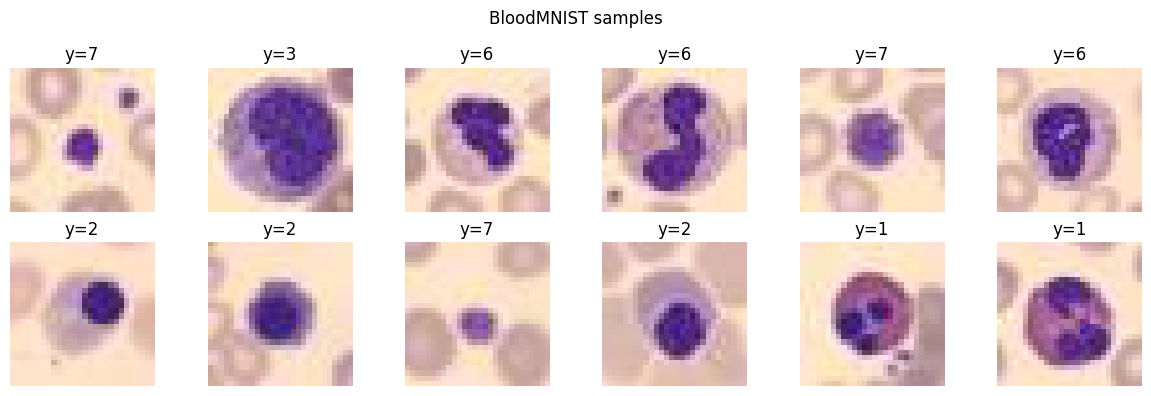

In [2]:
# ============================================================
# S2. DATASET LOADING + VALIDATION
# ============================================================

def load_medmnist_split(dataset_name: str, split: str, download: bool = True):
    if dataset_name not in INFO:
        raise ValueError(f"Unknown MedMNIST dataset: {dataset_name}")
    info = INFO[dataset_name]
    DataClass = getattr(medmnist, info["python_class"])
    ds = DataClass(split=split, download=download)

    imgs = np.asarray(ds.imgs)
    labels = np.asarray(ds.labels).reshape(-1).astype(np.int64)

    if imgs.ndim == 3:
        imgs = imgs[..., None]
    if imgs.shape[-1] == 1:
        imgs = np.repeat(imgs, 3, axis=-1)
    if imgs.shape[-1] != 3:
        raise ValueError(f"Expected RGB/grayscale data, got {imgs.shape}")

    X = torch.tensor(imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    y = torch.tensor(labels, dtype=torch.long)
    return X, y, info

def label_map_to_int(label_map):
    out = {}
    for k, v in label_map.items():
        try:
            out[int(k)] = str(v)
        except Exception:
            pass
    return dict(sorted(out.items()))

def resolve_class_id(label_map, hint, fallback, role):
    matches = [i for i, name in label_map.items() if hint.lower() in name.lower()]
    if len(matches) == 1:
        resolved = int(matches[0])
        if resolved != fallback:
            print(f"[class-id correction] {role}: configured {fallback}, metadata resolves '{hint}' -> {resolved}")
        return resolved
    msg = f"needs verification: could not uniquely resolve {role}='{hint}'. Using fallback id={fallback}."
    print("[warning]", msg)
    NEEDS_VERIFICATION.append(msg)
    return int(fallback)

X_train_raw, y_train_raw, dataset_info = load_medmnist_split(cfg.dataset_name, "train", download=True)
X_val_official, y_val_official, _ = load_medmnist_split(cfg.dataset_name, "val", download=True)
X_test_raw, y_test_raw, _ = load_medmnist_split(cfg.dataset_name, "test", download=True)

label_map = label_map_to_int(dataset_info.get("label", {}))
display(pd.DataFrame({"class_id": list(label_map.keys()), "class_name": list(label_map.values())}))

if len(label_map) != cfg.n_classes:
    msg = f"needs verification: expected {cfg.n_classes} classes, found {len(label_map)} in metadata."
    print("[warning]", msg)
    NEEDS_VERIFICATION.append(msg)

if cfg.auto_resolve_class_ids:
    cfg.source_class = resolve_class_id(label_map, cfg.source_name_hint, cfg.source_class, "source")
    cfg.target_class = resolve_class_id(label_map, cfg.target_name_hint, cfg.target_class, "target")

if cfg.source_class == cfg.target_class:
    raise ValueError("Source and target classes are identical. Fix cfg.source_class/cfg.target_class.")

print(f"Final source class: {cfg.source_class} | {label_map.get(cfg.source_class, 'unknown')}")
print(f"Final target class: {cfg.target_class} | {label_map.get(cfg.target_class, 'unknown')}")
print("Shapes:", X_train_raw.shape, X_val_official.shape, X_test_raw.shape)

def class_count_table(y, split):
    counts = pd.Series(y.cpu().numpy()).value_counts().sort_index()
    return pd.DataFrame({"split": split, "class_id": counts.index, "count": counts.values})

dist_df = pd.concat([
    class_count_table(y_train_raw, "train"),
    class_count_table(y_val_official, "val"),
    class_count_table(y_test_raw, "test"),
], ignore_index=True)
display(dist_df.pivot_table(index="class_id", columns="split", values="count", fill_value=0).astype(int))

def show_image_grid(X, y, n=12, title="Sample images"):
    n = min(n, len(X))
    cols = min(n, 6)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i].permute(1, 2, 0).cpu().numpy())
        plt.title(f"y={int(y[i])}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_image_grid(X_train_raw, y_train_raw, n=12, title="BloodMNIST samples")


## S3–S7. Architecture, preprocessing, split construction, and training helpers

The model is the preserved final architecture: ResNet-18 feature stem, BiGRU context bridge, 8-qubit/4-layer VQC with ZX_ALT readout, and a pure-QNN classifier head. There is no secondary ResNet classifier bypass.


In [3]:
# ============================================================
# S3-S7. MODEL + TRAINING HELPERS
# ============================================================

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def preprocess_for_resnet(x, model_image_size):
    x = F.interpolate(x, size=(model_image_size, model_image_size), mode="bilinear", align_corners=False)
    return (x - IMAGENET_MEAN.to(x.device)) / IMAGENET_STD.to(x.device)

def measurement_dim(n_qubits, obs_mode):
    obs = obs_mode.upper().strip()
    if obs in ["Z_ONLY", "ZX_ALT"]:
        return n_qubits
    if obs == "XYZ":
        return 3 * n_qubits
    raise ValueError(f"Unknown obs_mode={obs_mode}")

def make_vqc_qnode(n_qubits, n_layers, obs_mode="ZX_ALT"):
    try:
        dev = qml.device("lightning.qubit", wires=n_qubits)
    except Exception:
        print("[warning] lightning.qubit unavailable; using default.qubit")
        dev = qml.device("default.qubit", wires=n_qubits)
    obs = obs_mode.upper().strip()

    @qml.qnode(dev, interface="torch", diff_method="best")
    def circuit(angles, weights, input_scales, input_bias, trojan_angles, trigger_flag):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.Rot(weights[layer, q, 0], weights[layer, q, 1], weights[layer, q, 2], wires=q)
            for q in range(n_qubits):
                qml.RY(input_scales[layer, q] * angles[q] + input_bias[layer, q], wires=q)

            # Critical isolation: trigger_flag=0 disables the inserted QTrojan RY gate.
            for q in range(n_qubits):
                qml.RY(trigger_flag * trojan_angles[layer, q], wires=q)

            if layer % 2 == 0:
                for q in range(n_qubits):
                    qml.CNOT(wires=[q, (q + 1) % n_qubits])
            else:
                for q in range(n_qubits):
                    qml.CNOT(wires=[(q + 1) % n_qubits, q])

        if obs == "Z_ONLY":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        if obs == "XYZ":
            out = []
            for q in range(n_qubits):
                out.extend([qml.expval(qml.PauliX(q)), qml.expval(qml.PauliY(q)), qml.expval(qml.PauliZ(q))])
            return out
        return [qml.expval(qml.PauliZ(q)) if q % 2 == 0 else qml.expval(qml.PauliX(q)) for q in range(n_qubits)]
    return circuit

class StrongVQCMeasurementLayer(nn.Module):
    def __init__(self, in_dim, n_qubits, n_layers, obs_mode, trojan_init_std):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.obs_mode = obs_mode
        self.compress = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, 32),
            nn.Tanh(),
            nn.Linear(32, n_qubits),
            nn.Tanh(),
        )
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 3))
        self.input_scales = nn.Parameter(torch.ones(n_layers, n_qubits))
        self.input_bias = nn.Parameter(torch.zeros(n_layers, n_qubits))
        self.trojan_angles = nn.Parameter(trojan_init_std * torch.randn(n_layers, n_qubits))
        self.qnode = make_vqc_qnode(n_qubits, n_layers, obs_mode)

    def forward(self, context, trojan_mask=None):
        angles = math.pi * (self.compress(context) + 1.0) / 2.0
        if trojan_mask is None:
            trojan_mask = torch.zeros(angles.shape[0], device=angles.device, dtype=angles.dtype)
        else:
            trojan_mask = trojan_mask.to(device=angles.device, dtype=angles.dtype).view(-1)

        vals = [
            torch.stack(self.qnode(a, self.weights, self.input_scales, self.input_bias, self.trojan_angles, flag)).float()
            for a, flag in zip(angles, trojan_mask)
        ]
        return torch.stack(vals, dim=0)

class QMedShieldHybridQNN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        weights = None
        if cfg.use_imagenet_weights:
            try:
                weights = ResNet18_Weights.IMAGENET1K_V1
            except Exception:
                weights = None
        try:
            resnet = models.resnet18(weights=weights)
        except Exception as exc:
            msg = f"needs verification: ImageNet weights unavailable ({exc}); using random ResNet-18 init."
            print("[warning]", msg)
            NEEDS_VERIFICATION.append(msg)
            resnet = models.resnet18(weights=None)

        self.stem = nn.Sequential(*list(resnet.children())[:-2])
        if cfg.freeze_resnet_lower_blocks:
            for p in self.stem[:6].parameters():
                p.requires_grad = False

        self.rnn = nn.GRU(input_size=512, hidden_size=256, num_layers=2,
                          batch_first=True, bidirectional=True, dropout=0.2)
        self.vqc = StrongVQCMeasurementLayer(512, cfg.n_qubits, cfg.vqc_layers, cfg.obs_mode, cfg.trojan_init_std)
        self.q_head = nn.Linear(measurement_dim(cfg.n_qubits, cfg.obs_mode), cfg.n_classes)

    def _context(self, x_preprocessed):
        feats = self.stem(x_preprocessed)
        B, C, H, W = feats.shape
        seq = feats.view(B, C, H*W).permute(0, 2, 1)
        out, _ = self.rnn(seq)
        return out.mean(dim=1)

    def _mask(self, batch_size, device, t=0.0, trojan_mask=None):
        if trojan_mask is not None:
            return trojan_mask.to(device=device, dtype=torch.float32).view(-1)
        if isinstance(t, torch.Tensor):
            return t.to(device=device, dtype=torch.float32).view(-1)
        return torch.full((batch_size,), float(t), device=device, dtype=torch.float32)

    def forward(self, x_preprocessed, t=0.0, return_measurements=False, trojan_mask=None):
        ctx = self._context(x_preprocessed)
        mask = self._mask(ctx.shape[0], ctx.device, t=t, trojan_mask=trojan_mask)
        qfeat = self.vqc(ctx, trojan_mask=mask)
        logits = self.q_head(qfeat)
        if return_measurements:
            return logits, qfeat, ctx
        return logits

    @torch.no_grad()
    def extract_vqc_measurements(self, x_raw, t=0.0):
        xp = preprocess_for_resnet(x_raw, self.cfg.model_image_size)
        _, qfeat, _ = self.forward(xp, t=t, return_measurements=True)
        return qfeat

def verify_architecture(model, cfg, device):
    model = model.to(device)
    dummy = torch.rand(4, 3, cfg.native_image_size, cfg.native_image_size, device=device)
    xp = preprocess_for_resnet(dummy, cfg.model_image_size)
    logits, qfeat, ctx = model(xp, t=0, return_measurements=True)
    assert logits.shape == (4, cfg.n_classes), logits.shape
    assert qfeat.shape == (4, measurement_dim(cfg.n_qubits, cfg.obs_mode)), qfeat.shape
    assert ctx.shape == (4, 512), ctx.shape
    print("Architecture verified:", logits.shape, qfeat.shape, ctx.shape)

def stratified_limit_tensors(X, y, max_n, seed):
    if max_n is None or len(y) <= max_n:
        return X, y, np.arange(len(y))
    idx = np.arange(len(y))
    _, keep = train_test_split(idx, test_size=max_n, random_state=seed, stratify=y.cpu().numpy())
    keep = np.sort(keep)
    return X[keep], y[keep], keep

def make_train_val_split(X, y, cfg, seed):
    X_lim, y_lim, keep = stratified_limit_tensors(X, y, cfg.max_train_n, seed)
    idx = np.arange(len(y_lim))
    tr, va = train_test_split(idx, test_size=cfg.val_size, random_state=seed, stratify=y_lim.cpu().numpy())
    tr, va = np.sort(tr), np.sort(va)
    return {"X_train": X_lim[tr], "y_train": y_lim[tr], "X_val": X_lim[va], "y_val": y_lim[va], "source_idx": keep}

def augment_train_only(X, seed):
    set_all_seeds(seed)
    aug = T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomCrop(X.shape[-1], padding=2, padding_mode="reflect")])
    return torch.stack([aug(img) for img in X])

def make_loader(X, y, batch_size, shuffle):
    return DataLoader(TensorDataset(X.float(), y.long()), batch_size=batch_size, shuffle=shuffle, num_workers=0)

def set_trainable(module, trainable):
    for p in module.parameters():
        p.requires_grad = trainable

def optimizer_for_stage(model, cfg, stage):
    if stage == "trojan":
        params = []
        params.append({"params": [model.vqc.trojan_angles], "lr": cfg.lr_base * cfg.lr_trojan_mult})
        other_vqc = [p for n, p in model.vqc.named_parameters() if n != "trojan_angles" and p.requires_grad]
        if other_vqc:
            params.append({"params": other_vqc, "lr": cfg.lr_base})
        params.append({"params": model.q_head.parameters(), "lr": cfg.lr_base})
        return torch.optim.AdamW(params, weight_decay=cfg.weight_decay)

    return torch.optim.AdamW([
        {"params": model.stem[6:].parameters(), "lr": cfg.lr_base * 0.1},
        {"params": model.rnn.parameters(), "lr": cfg.lr_base},
        {"params": model.vqc.parameters(), "lr": cfg.lr_base},
        {"params": model.q_head.parameters(), "lr": cfg.lr_base},
    ], weight_decay=cfg.weight_decay)

@torch.no_grad()
def evaluate_classifier(model, X, y, cfg, device, trojan_t=0.0):
    model.eval()
    loader = make_loader(X, y, cfg.eval_batch_size, shuffle=False)
    preds, probs = [], []
    for xb, _ in loader:
        xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
        logits = model(xb, t=trojan_t)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        preds.append(prob.argmax(axis=1))
        probs.append(prob)
    preds = np.concatenate(preds)
    probs = np.concatenate(probs)
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    return {
        "accuracy": float(accuracy_score(y_np, preds)),
        "macro_f1": float(f1_score(y_np, preds, average="macro", zero_division=0)),
        "preds": preds,
        "probs": probs,
    }

@torch.no_grad()
def evaluate_qtrojan_asr(model, X, y, cfg, device, seed):
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    idx = np.where(y_np == cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for ASR.")
    rng = np.random.default_rng(seed)
    if cfg.max_asr_n and len(idx) > cfg.max_asr_n:
        idx = rng.choice(idx, size=cfg.max_asr_n, replace=False)
    idx = np.sort(idx)
    y_target = torch.full((len(idx),), cfg.target_class, dtype=torch.long)
    out = evaluate_classifier(model, X[idx], y_target, cfg, device, trojan_t=1.0)
    out["n_source_eval"] = int(len(idx))
    return out

def train_clean_stage(model, train_loader, val_loader, cfg, device):
    model = model.to(device)
    opt = optimizer_for_stage(model, cfg, "clean")
    hist = []
    print(f"Stage A clean training: {cfg.clean_epochs} epochs")
    for ep in range(1, cfg.clean_epochs + 1):
        model.train()
        loss_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()
            logits = model(xb, t=0.0)
            loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)
        val = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, 0.0)
        row = {"epoch": ep, "stage": "clean", "loss": loss_sum/max(n,1), "val_acc": val["accuracy"], "val_macro_f1": val["macro_f1"]}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_acc']:.4f}")
    return model, hist

def train_qtrojan_stage(model, train_loader, val_loader, cfg, device):
    """
    QTrojan optimization stage.

    The previous short run underfit the attack (ASR below the configured gate).
    This version keeps the classical encoder frozen by default, but adds a small
    source-only trigger boost so every epoch sees enough source->target attack
    signal without making the notebook too heavy for Kaggle T4.
    """
    model = model.to(device)
    if cfg.freeze_classical_in_trojan_stage:
        set_trainable(model.stem, False)
        set_trainable(model.rnn, False)
        print("Frozen ResNet/BiGRU during QTrojan stage.")
    set_trainable(model.vqc, True)
    set_trainable(model.q_head, True)

    # Source-only loader for stable trigger optimization.
    X_all, y_all = train_loader.dataset.tensors
    src_mask = (y_all == cfg.source_class)
    if int(src_mask.sum()) == 0:
        raise ValueError("No source-class samples in training split; cannot train QTrojan.")
    src_dataset = TensorDataset(X_all[src_mask], y_all[src_mask])
    src_loader = DataLoader(
        src_dataset,
        batch_size=min(cfg.train_batch_size, len(src_dataset)),
        shuffle=True,
        drop_last=False
    )

    opt = optimizer_for_stage(model, cfg, "trojan")
    hist = []
    print(f"Stage B QTrojan training: {cfg.qtrojan_epochs} epochs")
    for ep in range(1, cfg.qtrojan_epochs + 1):
        model.train()
        loss_sum, n, tbatches = 0.0, 0, 0

        # Mixed clean + in-batch source attack pass.
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()

            logits_clean = model(xb, t=0.0)
            loss_clean = F.cross_entropy(logits_clean, yb, label_smoothing=cfg.label_smoothing)

            src_idx = torch.where(yb == cfg.source_class)[0]
            if len(src_idx) > 0:
                target = torch.full((len(src_idx),), cfg.target_class, dtype=torch.long, device=device)
                logits_trig = model(xb[src_idx], t=1.0)
                loss_trig = F.cross_entropy(logits_trig, target)
                loss = cfg.clean_loss_weight_trojan * loss_clean + cfg.q_loss_weight_trojan * loss_trig
                tbatches += 1
            else:
                loss = cfg.clean_loss_weight_trojan * loss_clean

            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)

        # Lightweight source-only trigger boost. This usually improves ASR
        # without unfreezing the full ResNet/BiGRU stack.
        if cfg.qtrojan_source_boost_batches > 0:
            for b_i, (xs, _) in enumerate(src_loader):
                if b_i >= cfg.qtrojan_source_boost_batches:
                    break
                xs = preprocess_for_resnet(xs.to(device), cfg.model_image_size)
                target = torch.full((len(xs),), cfg.target_class, dtype=torch.long, device=device)
                opt.zero_grad()
                logits_trig = model(xs, t=1.0)
                loss_boost = cfg.q_loss_weight_trojan * F.cross_entropy(logits_trig, target)
                loss_boost.backward()
                opt.step()
                loss_sum += float(loss_boost.detach().cpu()) * len(xs)
                n += len(xs)
                tbatches += 1

        val_ca = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, 0.0)
        val_asr = evaluate_qtrojan_asr(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, cfg.primary_seed)
        row = {"epoch": ep, "stage": "qtrojan", "loss": loss_sum/max(n,1), "val_ca": val_ca["accuracy"], "val_asr": val_asr["accuracy"], "trojan_batches": tbatches}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_ca']:.4f}, val_ASR={row['val_asr']:.4f}")
        if val_ca["accuracy"] >= cfg.clean_acc_min and val_asr["accuracy"] >= cfg.asr_min:
            print("Early stop: CA/ASR gates reached.")
            break
    return model, hist


## S8–S13. Main QTrojan pipeline, CC-QMC detection, baselines, and leakage/claim verification

This section now separates three evidence types:

1. **Forced-`t=0` dormant control:** the QTrojan gate is disabled for every sample. If this fails, that does not automatically break the project; it shows the old dormant-detection claim is unsupported.
2. **Trigger-on diagnostic:** positives run with `t=1`, negatives with `t=0`. This is useful but can be accused of oracle leakage if reported carelessly.
3. **Paired active QTrojan audit:** same source-class image distribution is evaluated under `t=0` and `t=1`; active samples are kept as a minority. This is the strongest lightweight claim for QTrojan-state detection.


In [4]:
# ============================================================
# S8-S13. QTROJAN PIPELINE + CC-QMC DETECTION
# ============================================================

@torch.no_grad()
def extract_measurements_and_context(model, X, cfg, device, trojan_mask_np=None, t_forced=None):
    model.eval()
    if t_forced is not None:
        masks = torch.full((len(X),), float(t_forced), dtype=torch.float32)
    elif trojan_mask_np is not None:
        masks = torch.tensor(trojan_mask_np, dtype=torch.float32)
    else:
        masks = torch.zeros(len(X), dtype=torch.float32)
    qs, ctxs, preds = [], [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
        tb = masks[s:e].to(device)
        logits, qfeat, ctx = model(xb, trojan_mask=tb, return_measurements=True)
        qs.append(qfeat.cpu())
        ctxs.append(ctx.cpu())
        preds.append(logits.argmax(dim=1).cpu())
    return torch.cat(qs).numpy(), torch.cat(ctxs).numpy(), torch.cat(preds).numpy()

@torch.no_grad()
def extract_delta_measurements(model, X, cfg, device):
    model.eval()
    feats, ctxs = [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
        b = xb.shape[0]
        zeros = torch.zeros(b, device=device)
        ones = torch.ones(b, device=device)
        _, q0, ctx = model(xb, trojan_mask=zeros, return_measurements=True)
        _, q1, _ = model(xb, trojan_mask=ones, return_measurements=True)
        feats.append(torch.cat([q0, q1, torch.abs(q1-q0)], dim=1).cpu())
        ctxs.append(ctx.cpu())
    return torch.cat(feats).numpy(), torch.cat(ctxs).numpy()

def build_detection_pool(X_test, y_test, cfg, seed):
    """
    Plan-aligned detection pool:
    clean-source + clean-target + all remaining source samples as logical triggered-source.

    This avoids the older 10% anomaly shortcut and makes the pool composition explicit.
    If a class has fewer than 500 examples, the function uses the largest feasible balanced count.
    """
    y_np = y_test.cpu().numpy()
    source_idx = np.where(y_np == cfg.source_class)[0]
    target_idx = np.where(y_np == cfg.target_class)[0]
    if len(source_idx) < 20 or len(target_idx) < 10:
        raise ValueError(
            f"Insufficient source/target samples: source={len(source_idx)}, target={len(target_idx)}"
        )

    rng = np.random.default_rng(seed)
    sp = rng.permutation(source_idx)
    tp = rng.permutation(target_idx)

    # Need enough source samples left for logical triggered-source.
    clean_n = min(cfg.detection_pair_n, len(target_idx), max(1, len(source_idx) // 2))
    clean_source_idx = sp[:clean_n]
    backdoor_source_idx = sp[clean_n:]     # all remaining source samples are trigger-test candidates
    clean_target_idx = tp[:clean_n]

    if len(backdoor_source_idx) < 1:
        raise ValueError("Detection pool has no logical backdoor source samples after clean-source allocation.")

    X_det = torch.cat(
        [X_test[clean_source_idx], X_test[clean_target_idx], X_test[backdoor_source_idx]],
        dim=0
    )

    is_backdoor = np.concatenate([
        np.zeros(len(clean_source_idx), dtype=bool),
        np.zeros(len(clean_target_idx), dtype=bool),
        np.ones(len(backdoor_source_idx), dtype=bool),
    ])

    group_names = np.array(
        ["clean_source"] * len(clean_source_idx)
        + ["clean_target"] * len(clean_target_idx)
        + ["logical_backdoor_source"] * len(backdoor_source_idx)
    )

    mask_t0 = np.zeros(len(X_det), dtype=np.float32)
    mask_trigger_diag = is_backdoor.astype(np.float32)

    print(
        f"Detection pool: {len(clean_source_idx)} clean-source + "
        f"{len(clean_target_idx)} clean-target + "
        f"{len(backdoor_source_idx)} logical-backdoor-source = {len(X_det)}"
    )
    return {
        "X_det": X_det,
        "is_backdoor": is_backdoor,
        "group_names": group_names,
        "mask_t0": mask_t0,
        "mask_trigger_diag": mask_trigger_diag,
    }


def build_paired_active_qtrojan_pool(X_test, y_test, cfg, seed):
    """
    Paired active QTrojan audit pool.

    Purpose:
    Compare clean and activated executions of source-class images while controlling
    image/class identity. Active samples remain a minority so K3-minority logic is
    still meaningful.

    This is NOT a dormant t=0 detector. It is an active-trigger measurement audit:
    can quantum measurements expose the QTrojan state when the trigger gate is active?
    """
    y_np = y_test.cpu().numpy()
    source_idx = np.where(y_np == cfg.source_class)[0]
    if len(source_idx) < 20:
        raise ValueError(f"Insufficient source samples for paired active audit: {len(source_idx)}")

    rng = np.random.default_rng(seed)
    sp = rng.permutation(source_idx)

    n_clean = min(cfg.detection_pair_n, len(sp))
    n_active = max(1, int(round(n_clean * cfg.active_trigger_fraction)))
    n_active = min(n_active, n_clean)

    clean_idx = sp[:n_clean]
    active_idx = clean_idx[:n_active]  # same source-image distribution; duplicated under t=1

    X_pair = torch.cat([X_test[clean_idx], X_test[active_idx]], dim=0)
    is_active = np.concatenate([
        np.zeros(len(clean_idx), dtype=bool),
        np.ones(len(active_idx), dtype=bool)
    ])
    group_names = np.array(
        ["source_t0_clean"] * len(clean_idx)
        + ["source_t1_active"] * len(active_idx)
    )
    masks = is_active.astype(np.float32)

    print(
        f"Paired active QTrojan audit pool: {len(clean_idx)} source t=0 clean + "
        f"{len(active_idx)} same-distribution source t=1 active = {len(X_pair)}"
    )

    return {
        "X_pair": X_pair,
        "is_active": is_active,
        "group_names": group_names,
        "masks": masks,
    }


class ReducerWrapper:
    def __init__(self, n_components, seed):
        self.n_components = n_components
        self.seed = seed
        self.scaler = StandardScaler()
        self.reducer = None

    def fit_transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        Xs = self.scaler.fit_transform(X)
        n_comp = min(self.n_components, Xs.shape[0]-1, Xs.shape[1])
        if n_comp < 1:
            return Xs
        try:
            self.reducer = FastICA(n_components=n_comp, random_state=self.seed, max_iter=1000, whiten="unit-variance")
            return self.reducer.fit_transform(Xs)
        except Exception as exc:
            print(f"[warning] FastICA failed ({exc}); using PCA.")
            self.reducer = PCA(n_components=n_comp, random_state=self.seed)
            return self.reducer.fit_transform(Xs)

    def transform(self, X):
        Xs = self.scaler.transform(np.asarray(X, dtype=np.float32))
        return self.reducer.transform(Xs) if self.reducer is not None else Xs

def fit_kmeans_minority_detector(A, is_backdoor, cfg, seed, k=None, group_names=None):
    k = k or cfg.k_clusters
    y = np.asarray(is_backdoor).astype(bool)
    reducer = ReducerWrapper(cfg.ica_components, seed)
    V = reducer.fit_transform(A)
    km = KMeans(n_clusters=k, n_init=cfg.kmeans_n_init, random_state=seed)
    cluster_ids = km.fit_predict(V)
    counts = np.bincount(cluster_ids, minlength=k)
    bd_cluster = int(np.argmin(counts))
    pred = cluster_ids == bd_cluster
    centers = km.cluster_centers_
    d_bd = np.linalg.norm(V - centers[bd_cluster], axis=1)
    others = [j for j in range(k) if j != bd_cluster]
    d_other = np.min(np.stack([np.linalg.norm(V - centers[j], axis=1) for j in others], axis=1), axis=1)
    scores = d_other - d_bd
    try:
        sil = float(silhouette_score(V, cluster_ids))
    except Exception:
        sil = np.nan
    metrics = {
        "det_acc": float(accuracy_score(y, pred)),
        "det_f1": float(f1_score(y, pred, zero_division=0)),
        "det_precision": float(precision_score(y, pred, zero_division=0)),
        "det_recall": float(recall_score(y, pred, zero_division=0)),
        "det_auprc": float(average_precision_score(y.astype(int), scores)),
        "true_backdoor_rate": float(y.mean()),
        "pred_backdoor_rate": float(pred.mean()),
        "mean_silhouette": sil,
        "cluster_counts": counts.tolist(),
        "selected_cluster": bd_cluster,
    }
    if group_names is not None:
        display(pd.crosstab(pd.Series(cluster_ids, name="cluster"), pd.Series(group_names, name="group")))
    return {"metrics": metrics, "pred": pred, "scores": scores, "V": V, "cluster_ids": cluster_ids, "reducer": reducer, "kmeans": km, "backdoor_cluster": bd_cluster}


def detector_score_matrix(A, detector):
    """
    Score samples using an already-fitted reducer + KMeans detector.

    Positive score means closer to the selected minority/backdoor centroid than to
    the nearest non-backdoor centroid.
    """
    V = detector["reducer"].transform(A)
    centers = detector["kmeans"].cluster_centers_
    bd = detector["backdoor_cluster"]

    d_bd = np.linalg.norm(V - centers[bd], axis=1)
    others = [j for j in range(len(centers)) if j != bd]
    d_other = np.min(
        np.stack([np.linalg.norm(V - centers[j], axis=1) for j in others], axis=1),
        axis=1
    )
    return d_other - d_bd

def calibrate_threshold_from_clean_scores(clean_scores, target_fpr):
    clean_scores = np.asarray(clean_scores, dtype=np.float32)
    return float(np.percentile(clean_scores, (1 - target_fpr) * 100))

def calibrate_threshold(scores, is_backdoor, target_fpr):
    clean_scores = np.asarray(scores)[~np.asarray(is_backdoor).astype(bool)]
    return float(np.percentile(clean_scores, (1-target_fpr)*100))

def threshold_metrics(scores, is_backdoor, tau):
    y = np.asarray(is_backdoor).astype(int)
    pred = (np.asarray(scores) > tau).astype(int)
    return {
        "tau": tau,
        "f1_at_tau": float(f1_score(y, pred, zero_division=0)),
        "precision_at_tau": float(precision_score(y, pred, zero_division=0)),
        "recall_at_tau": float(recall_score(y, pred, zero_division=0)),
        "auprc": float(average_precision_score(y, scores)),
        "empirical_fpr": float(((pred == 1) & (y == 0)).sum() / max((y == 0).sum(), 1)),
    }

def run_pipeline(seed, cfg, device):
    set_all_seeds(seed)
    print("\n" + "="*90)
    print(f"QMedShield seed={seed} | source={cfg.source_class} -> target={cfg.target_class}")
    print("="*90)

    split = make_train_val_split(X_train_raw, y_train_raw, cfg, seed)
    X_train_aug = augment_train_only(split["X_train"], seed)
    train_loader = make_loader(X_train_aug, split["y_train"], cfg.train_batch_size, True)
    val_loader = make_loader(split["X_val"], split["y_val"], cfg.eval_batch_size, False)

    model = QMedShieldHybridQNN(cfg).to(device)
    verify_architecture(model, cfg, device)
    model, hist_clean = train_clean_stage(model, train_loader, val_loader, cfg, device)

    # v7: Save the Stage-A clean-trained model state before injecting QTrojan.
    # This is the correct clean reference for circuit compromise audit.
    # A fresh random model is not a fair reference.
    clean_model_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model, hist_trojan = train_qtrojan_stage(model, train_loader, val_loader, cfg, device)

    X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, seed)
    clean_eval = evaluate_classifier(model, X_test_limited, y_test_limited, cfg, device, 0.0)
    asr_eval = evaluate_qtrojan_asr(model, X_test_raw, y_test_raw, cfg, device, seed)

    print(f"[Attack Gate] CA={clean_eval['accuracy']:.4f} | ASR={asr_eval['accuracy']:.4f}")
    if asr_eval["accuracy"] < cfg.asr_min:
        msg = f"needs verification: ASR {asr_eval['accuracy']:.4f} below configured gate {cfg.asr_min:.2f}."
        print("[warning]", msg)
        NEEDS_VERIFICATION.append(msg)
        if cfg.strict_attack_gate:
            raise RuntimeError(msg)

    det = build_detection_pool(X_test_raw, y_test_raw, cfg, seed)
    X_det, is_backdoor, group_names = det["X_det"], det["is_backdoor"], det["group_names"]

    print("\nPrimary valid extraction: all samples t=0")
    A_q_t0, A_ctx_t0, preds_t0 = extract_measurements_and_context(model, X_det, cfg, device, t_forced=0.0)

    print("\nTrigger-on diagnostic extraction: backdoor group t=1 (leakage-prone)")
    A_q_diag, A_ctx_diag, preds_diag = extract_measurements_and_context(model, X_det, cfg, device, trojan_mask_np=det["mask_trigger_diag"])

    print("\nDelta audit extraction")
    A_q_delta, A_ctx_delta = extract_delta_measurements(model, X_det, cfg, device)

    raw_flat = X_det.reshape(len(X_det), -1).numpy().astype(np.float32)

    methods = {}
    print("\nRaw K3 baseline")
    methods["Raw_K3_Minority"] = fit_kmeans_minority_detector(raw_flat, is_backdoor, cfg, seed, group_names=group_names)
    print("\nContext K3 baseline")
    methods["Ctx_K3_Minority_T0"] = fit_kmeans_minority_detector(A_ctx_t0, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC primary forced t=0 K3")
    methods["CC_QMC_PRIMARY_T0_K3"] = fit_kmeans_minority_detector(A_q_t0, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC trigger-on diagnostic K3")
    methods["CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3"] = fit_kmeans_minority_detector(A_q_diag, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC delta/counterfactual K3 on plan pool")
    methods["CC_QMC_DELTA_K3"] = fit_kmeans_minority_detector(A_q_delta, is_backdoor, cfg, seed, group_names=group_names)

    # Paired active QTrojan audit: applies t=0 and t=1 to the same source-class image distribution.
    # This avoids the misleading dormant forced-t0 claim while also avoiding class confounding.
    paired_active_artifact = None
    if cfg.pair_same_images_for_qtrojan_detection:
        print("\nCC-QMC paired active QTrojan audit")
        pair = build_paired_active_qtrojan_pool(X_test_raw, y_test_raw, cfg, seed)
        A_pair_q, A_pair_ctx, _ = extract_measurements_and_context(
            model, pair["X_pair"], cfg, device, trojan_mask_np=pair["masks"]
        )
        paired_active_artifact = {
            "pair": pair,
            "A_pair_q": A_pair_q,
            "A_pair_ctx": A_pair_ctx,
        }
        methods["CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT"] = fit_kmeans_minority_detector(
            A_pair_q, pair["is_active"], cfg, seed, group_names=pair["group_names"]
        )

    rows = []
    for name, out in methods.items():
        row = {"seed": seed, "method": name, "clean_accuracy": clean_eval["accuracy"], "asr": asr_eval["accuracy"]}
        row.update(out["metrics"])
        rows.append(row)
    results_df = pd.DataFrame(rows).sort_values("det_f1", ascending=False)
    display(results_df)

    primary = methods["CC_QMC_PRIMARY_T0_K3"]

    # Calibrate the 5% clean-FPR threshold on clean validation measurements,
    # then apply it to the held-out detection pool. This avoids evaluation-pool threshold leakage.
    A_val_t0, _, _ = extract_measurements_and_context(model, split["X_val"], cfg, device, t_forced=0.0)
    val_scores = detector_score_matrix(A_val_t0, primary)
    tau = calibrate_threshold_from_clean_scores(val_scores, cfg.fpr_target)
    tmetrics = threshold_metrics(primary["scores"], is_backdoor, tau)
    print("Validation-calibrated threshold metrics for primary t=0 detector:", tmetrics)

    primary_f1 = methods["CC_QMC_PRIMARY_T0_K3"]["metrics"]["det_f1"]
    diag_f1 = methods["CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3"]["metrics"]["det_f1"]
    paired_f1 = methods.get("CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT", {}).get("metrics", {}).get("det_f1", np.nan)

    if diag_f1 > primary_f1 + 0.20:
        msg = (
            "forced-t0 dormant control is much weaker than trigger-on detection. "
            "Do not claim old ACTIVE result as dormant detection; report it only under an active-trigger audit threat model."
        )
        print("[critical warning]", msg)
        NEEDS_VERIFICATION.append("needs verification: " + msg)

    if not np.isnan(paired_f1) and paired_f1 > primary_f1 + 0.20:
        print(
            "[claim guidance] Paired active audit is stronger than forced-t0 control. "
            "This supports active QTrojan-state detection, not dormant t=0 detection."
        )

    return {
        "seed": seed,
        "model": model,
        "clean_model_state_dict": clean_model_state_dict,
        "split": split,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "clean_eval": clean_eval,
        "asr_eval": asr_eval,
        "det": det,
        "A_q_t0": A_q_t0,
        "A_ctx_t0": A_ctx_t0,
        "A_q_diag": A_q_diag,
        "A_q_delta": A_q_delta,
        "preds_t0": preds_t0,
        "methods": methods,
        "paired_active_artifact": paired_active_artifact,
        "results_df": results_df,
        "threshold_metrics": tmetrics,
        "history_df": pd.DataFrame(hist_clean + hist_trojan),
    }

primary_artifact = None
summary_df = pd.DataFrame()

if RUN_MAIN_EXPERIMENT:
    primary_artifact = run_pipeline(cfg.primary_seed, cfg, DEVICE)
    summary_df = primary_artifact["results_df"].copy()
    summary_path = os.path.join(cfg.out_dir, "qmedshield_primary_results.csv")
    summary_df.to_csv(summary_path, index=False)
    print("Saved:", summary_path)

    if SAVE_CHECKPOINTS:
        ckpt_path = os.path.join(cfg.out_dir, f"qmedshield_model_seed{cfg.primary_seed}.pt")
        torch.save({
            "model_state_dict": primary_artifact["model"].state_dict(),
            "clean_model_state_dict": primary_artifact.get("clean_model_state_dict"),
            "config": asdict(cfg),
            "clean_eval": primary_artifact["clean_eval"],
            "asr_eval": primary_artifact["asr_eval"],
            "threshold_metrics": primary_artifact["threshold_metrics"],
        }, ckpt_path)
        print("Saved checkpoint:", ckpt_path)

    # Explicit leakage verification summary.
    leak_rows = []
    for method_name in [
        "CC_QMC_PRIMARY_T0_K3",
        "CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3",
        "CC_QMC_DELTA_K3",
        "CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT",
        "Raw_K3_Minority",
        "Ctx_K3_Minority_T0",
    ]:
        if method_name not in primary_artifact["methods"]:
            continue
        m = primary_artifact["methods"][method_name]["metrics"]
        leak_rows.append({
            "method": method_name,
            "det_f1": m["det_f1"],
            "precision": m["det_precision"],
            "recall": m["det_recall"],
            "auprc": m["det_auprc"],
            "valid_claim_scope": (
                "dormant_t0_control_only" if method_name == "CC_QMC_PRIMARY_T0_K3"
                else "active_qtrojan_audit" if method_name == "CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT"
                else "diagnostic_or_baseline"
            ),
        })

    leakage_check_df = pd.DataFrame(leak_rows)
    display(leakage_check_df)
    leakage_path = os.path.join(cfg.out_dir, "leakage_verification_summary.csv")
    leakage_check_df.to_csv(leakage_path, index=False)
    print("Saved leakage verification:", leakage_path)

    primary_f1 = leakage_check_df.loc[
        leakage_check_df["method"] == "CC_QMC_PRIMARY_T0_K3", "det_f1"
    ].iloc[0]
    if primary_f1 < 0.80:
        NEEDS_VERIFICATION.append(
            "needs verification: forced-t0 dormant control is weak. This is expected for a trigger-controlled circuit gate; do not claim old ACTIVE K3 result as forced-t0 detection."
        )
else:
    print("RUN_MAIN_EXPERIMENT=False; main pipeline skipped.")



QMedShield seed=42 | source=1 -> target=6
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 20.0MB/s]


Architecture verified: torch.Size([4, 8]) torch.Size([4, 8]) torch.Size([4, 512])
Stage A clean training: 10 epochs
Epoch 01: loss=1.8890, val_CA=0.6581
Epoch 02: loss=1.6360, val_CA=0.7076
Epoch 03: loss=1.4825, val_CA=0.7762
Epoch 04: loss=1.3589, val_CA=0.7571
Epoch 05: loss=1.2551, val_CA=0.7714
Epoch 06: loss=1.1610, val_CA=0.8638
Epoch 07: loss=1.0892, val_CA=0.8638
Epoch 08: loss=0.9958, val_CA=0.8686
Epoch 09: loss=0.9585, val_CA=0.8905
Epoch 10: loss=0.9192, val_CA=0.8771
Frozen ResNet/BiGRU during QTrojan stage.
Stage B QTrojan training: 14 epochs
Epoch 01: loss=1.7541, val_CA=0.5305, val_ASR=0.7330
Epoch 02: loss=1.1504, val_CA=0.4143, val_ASR=0.8901
Epoch 03: loss=0.9367, val_CA=0.5857, val_ASR=0.9424
Epoch 04: loss=0.8150, val_CA=0.6762, val_ASR=0.9843
Epoch 05: loss=0.7566, val_CA=0.6162, val_ASR=0.9948
Epoch 06: loss=0.6909, val_CA=0.6352, val_ASR=0.9948
Epoch 07: loss=0.6567, val_CA=0.7257, val_ASR=0.9372
Early stop: CA/ASR gates reached.
[Attack Gate] CA=0.7025 | ASR=0

group,clean_source,clean_target,logical_backdoor_source
cluster,,,
0,167,26,151
1,83,238,96
2,62,48,65



Context K3 baseline


...

group,source_t0_clean,source_t1_active
cluster,,
0,227,14
1,157,0
2,116,36


,seed,method,clean_accuracy,asr,det_acc,det_f1,det_precision,det_recall,det_auprc,true_backdoor_rate,pred_backdoor_rate,mean_silhouette,cluster_counts,selected_cluster
5,42,CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT,0.7025,0.947115,0.763636,0.356436,0.236842,0.720000,0.192717,0.090909,0.276364,0.458747,"[241, 157, 152]",2
4,42,CC_QMC_DELTA_K3,0.7025,0.947115,0.598291,0.306273,0.360870,0.266026,0.376995,0.333333,0.245726,0.596263,"[431, 275, 230]",2
1,42,Ctx_K3_Minority_T0,0.7025,0.947115,0.599359,0.301676,0.360000,0.259615,0.404670,0.333333,0.240385,0.523842,"[381, 330, 225]",2
2,42,CC_QMC_PRIMARY_T0_K3,0.7025,0.947115,0.594017,0.293680,0.349558,0.253205,0.376934,0.333333,0.241453,0.568088,"[289, 421, 226]",2
0,42,Raw_K3_Minority,0.7025,0.947115,0.618590,0.266940,0.371429,0.208333,0.347533,0.333333,0.186966,0.197852,"[344, 417, 175]",2
3,42,CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3,0.7025,0.947115,0.513889,0.038055,0.055901,0.028846,0.318530,0.333333,0.172009,0.465662,"[262, 513, 161]",2


Validation-calibrated threshold metrics for primary t=0 detector: {'tau': 1.8578693866729736, 'f1_at_tau': 0.14698162729658792, 'precision_at_tau': 0.4057971014492754, 'recall_at_tau': 0.08974358974358974, 'auprc': 0.3769336178640864, 'empirical_fpr': 0.06570512820512821}
Saved: ./qmedshield_final_outputs/qmedshield_primary_results.csv
Saved checkpoint: ./qmedshield_final_outputs/qmedshield_model_seed42.pt


,method,det_f1,precision,recall,auprc,valid_claim_scope
0,CC_QMC_PRIMARY_T0_K3,0.293680,0.349558,0.253205,0.376934,dormant_t0_control_only
1,CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3,0.038055,0.055901,0.028846,0.318530,diagnostic_or_baseline
2,CC_QMC_DELTA_K3,0.306273,0.360870,0.266026,0.376995,diagnostic_or_baseline
3,CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT,0.356436,0.236842,0.720000,0.192717,active_qtrojan_audit
4,Raw_K3_Minority,0.266940,0.371429,0.208333,0.347533,diagnostic_or_baseline
5,Ctx_K3_Minority_T0,0.301676,0.360000,0.259615,0.404670,diagnostic_or_baseline


Saved leakage verification: ./qmedshield_final_outputs/leakage_verification_summary.csv


## S14. Visualizations and error analysis

All visuals are generated from computed artifacts. No figure is created from expected or proposal values.


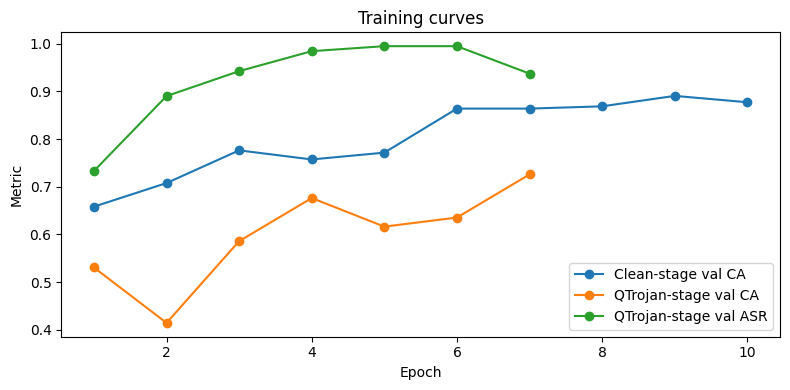

Saved: ./qmedshield_final_outputs/training_curves.png


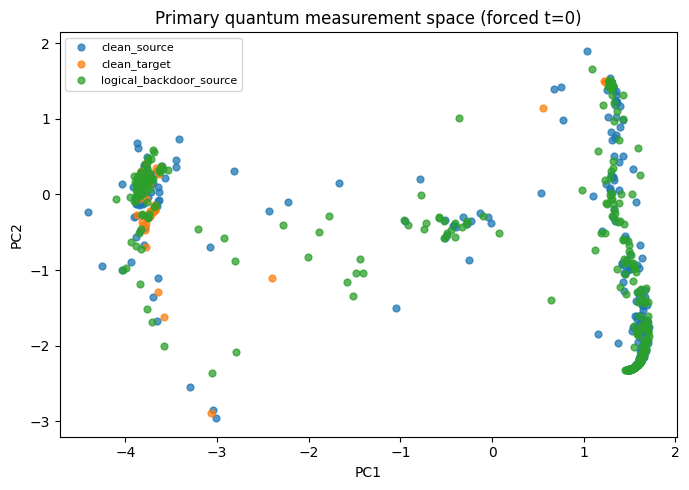

Saved: ./qmedshield_final_outputs/primary_t0_measurement_pca.png


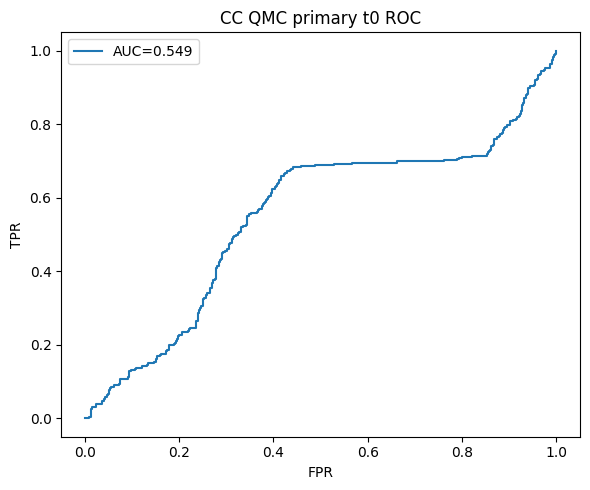

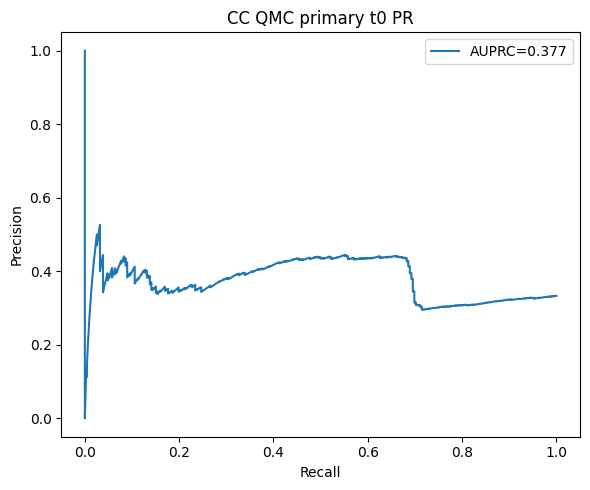

Saved: ./qmedshield_final_outputs/cc_qmc_primary_t0_roc.png ./qmedshield_final_outputs/cc_qmc_primary_t0_pr.png


,count
error_type,
correct,556
false_negative,233
false_positive,147


,group,is_backdoor,score,pred_backdoor,cluster_id,error_type
309,clean_source,False,2.430916,True,2,false_positive
469,clean_target,False,2.362148,True,2,false_positive
53,clean_source,False,2.350599,True,2,false_positive
47,clean_source,False,2.322014,True,2,false_positive
25,clean_source,False,2.275763,True,2,false_positive
23,clean_source,False,2.265422,True,2,false_positive
696,logical_backdoor_source,True,2.232421,True,2,correct
210,clean_source,False,2.226825,True,2,false_positive
111,clean_source,False,2.200275,True,2,false_positive
706,logical_backdoor_source,True,2.199141,True,2,correct


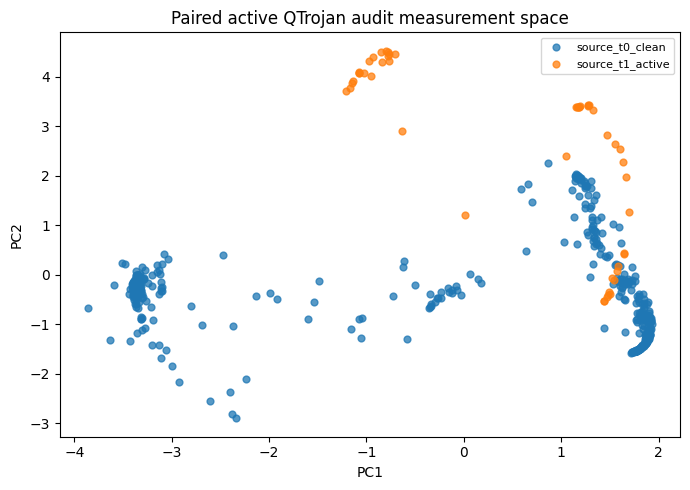

Saved: ./qmedshield_final_outputs/paired_active_qtrojan_audit_pca.png


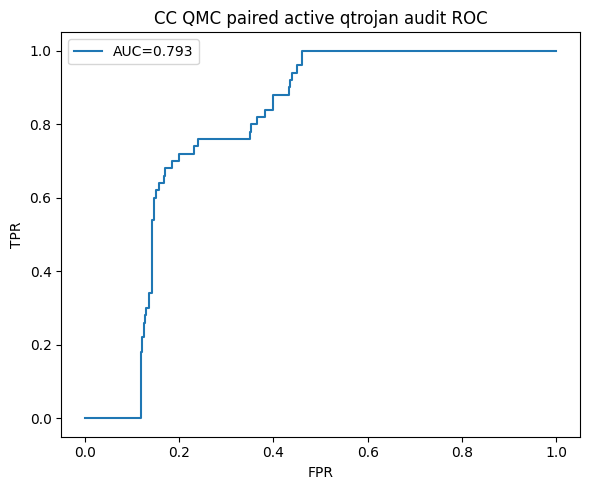

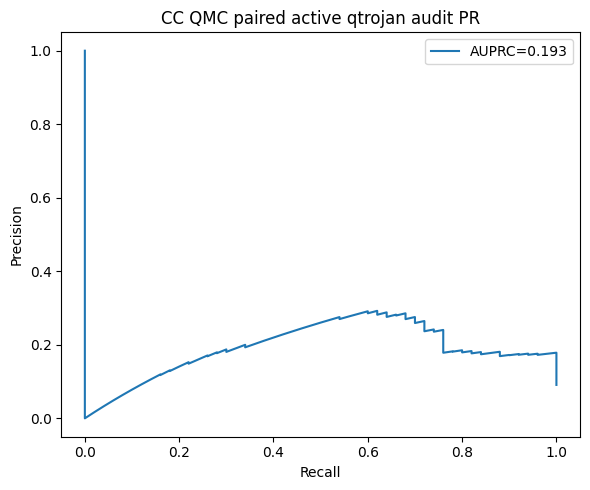

Saved: ./qmedshield_final_outputs/cc_qmc_paired_active_qtrojan_audit_roc.png ./qmedshield_final_outputs/cc_qmc_paired_active_qtrojan_audit_pr.png
Clean test classification report:
              precision    recall  f1-score   support

           0       0.78      0.54      0.64        85
           1       1.00      0.35      0.52       219
           2       0.88      0.72      0.79       109
           3       0.45      0.95      0.61       203
           4       0.84      0.87      0.86        85
           5       0.73      0.24      0.36       100
           6       0.72      0.82      0.77       234
           7       0.99      0.96      0.98       165

    accuracy                           0.70      1200
   macro avg       0.80      0.68      0.69      1200
weighted avg       0.79      0.70      0.69      1200



In [5]:
# ============================================================
# S14. VISUALIZATION + ERROR ANALYSIS
# ============================================================

def plot_training_history(history_df, out_dir):
    if history_df is None or history_df.empty:
        print("No training history available.")
        return
    plt.figure(figsize=(8, 4))
    clean = history_df[history_df["stage"] == "clean"]
    trojan = history_df[history_df["stage"] == "qtrojan"]
    if not clean.empty:
        plt.plot(clean["epoch"], clean["val_acc"], marker="o", label="Clean-stage val CA")
    if not trojan.empty:
        plt.plot(trojan["epoch"], trojan["val_ca"], marker="o", label="QTrojan-stage val CA")
        plt.plot(trojan["epoch"], trojan["val_asr"], marker="o", label="QTrojan-stage val ASR")
    plt.xlabel("Epoch"); plt.ylabel("Metric"); plt.title("Training curves")
    plt.legend(); plt.tight_layout()
    path = os.path.join(out_dir, "training_curves.png")
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

def plot_pca_measurements(A, group_names, out_dir, title, filename):
    X2 = PCA(n_components=2, random_state=cfg.primary_seed).fit_transform(StandardScaler().fit_transform(A))
    plt.figure(figsize=(7, 5))
    for g in list(dict.fromkeys(group_names.tolist())):
        mask = group_names == g
        plt.scatter(X2[mask, 0], X2[mask, 1], s=24, alpha=0.75, label=g)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(title); plt.legend(fontsize=8)
    plt.tight_layout()
    path = os.path.join(out_dir, filename)
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

def plot_detection_curves(scores, labels, out_dir, prefix):
    labels = np.asarray(labels).astype(int)
    if len(np.unique(labels)) < 2:
        print("Need both clean and backdoor labels for detection curves.")
        return
    fpr_arr, tpr_arr, _ = roc_curve(labels, scores)
    prec_arr, rec_arr, _ = precision_recall_curve(labels, scores)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr_arr, tpr_arr, label=f"AUC={auc(fpr_arr, tpr_arr):.3f}")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(prefix + " ROC"); plt.legend()
    plt.tight_layout()
    roc_path = os.path.join(out_dir, prefix.replace(" ", "_").lower() + "_roc.png")
    plt.savefig(roc_path, dpi=180, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(rec_arr, prec_arr, label=f"AUPRC={average_precision_score(labels, scores):.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(prefix + " PR"); plt.legend()
    plt.tight_layout()
    pr_path = os.path.join(out_dir, prefix.replace(" ", "_").lower() + "_pr.png")
    plt.savefig(pr_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", roc_path, pr_path)

def error_analysis_detection(artifact):
    primary = artifact["methods"]["CC_QMC_PRIMARY_T0_K3"]
    df = pd.DataFrame({
        "group": artifact["det"]["group_names"],
        "is_backdoor": artifact["det"]["is_backdoor"],
        "score": primary["scores"],
        "pred_backdoor": primary["pred"],
        "cluster_id": primary["cluster_ids"],
    })
    df["error_type"] = np.where(
        df["is_backdoor"] & ~df["pred_backdoor"], "false_negative",
        np.where(~df["is_backdoor"] & df["pred_backdoor"], "false_positive", "correct")
    )
    display(df["error_type"].value_counts().to_frame("count"))
    display(df.sort_values("score", ascending=False).head(15))
    df.to_csv(os.path.join(cfg.out_dir, "primary_t0_detection_error_analysis.csv"), index=False)
    return df

if primary_artifact is not None:
    plot_training_history(primary_artifact["history_df"], cfg.out_dir)
    plot_pca_measurements(
        primary_artifact["A_q_t0"], primary_artifact["det"]["group_names"], cfg.out_dir,
        "Primary quantum measurement space (forced t=0)", "primary_t0_measurement_pca.png"
    )
    primary_detector = primary_artifact["methods"]["CC_QMC_PRIMARY_T0_K3"]
    plot_detection_curves(primary_detector["scores"], primary_artifact["det"]["is_backdoor"], cfg.out_dir, "CC QMC primary t0")
    det_error_df = error_analysis_detection(primary_artifact)

    # Paired active audit visualization, if enabled.
    if "CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT" in primary_artifact["methods"]:
        pair_art = primary_artifact.get("paired_active_artifact")
        if pair_art is not None:
            plot_pca_measurements(
                pair_art["A_pair_q"], pair_art["pair"]["group_names"], cfg.out_dir,
                "Paired active QTrojan audit measurement space", "paired_active_qtrojan_audit_pca.png"
            )
            paired_detector = primary_artifact["methods"]["CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT"]
            plot_detection_curves(
                paired_detector["scores"], pair_art["pair"]["is_active"], cfg.out_dir,
                "CC QMC paired active qtrojan audit"
            )

    X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, cfg.primary_seed)
    print("Clean test classification report:")
    print(classification_report(y_test_limited.cpu().numpy(), primary_artifact["clean_eval"]["preds"], zero_division=0))
else:
    print("Run main experiment before visualization.")


## S15–S17. QXAI attribution and Defense B circuit repair

Default repair target is `trojan_angles`, because those are the actual inserted QTrojan RY gates. This is more faithful than repairing unrelated generic VQC weights. If you need the exact plan variant over `weights`, set `cfg.repair_parameter_name = "weights"`.


## Claim guard after leakage verification

Use the computed notebook outputs, not the old proposal table, as the final evidence. If forced-`t=0` CC-QMC remains weak, it must be reported as a dormant/null-control result. The active-trigger or paired audit can be discussed only as activated QTrojan behavior, not as proof that dormant poisoned circuits are detectable without activation.

The repair cell below avoids `copy.deepcopy()` because PennyLane Lightning QNodes/devices are not pickle-safe. It rebuilds the model and loads the trained `state_dict`, which is the correct clone method for this notebook.


Parameter-shift attribution on: trojan_angles
QXAI attribution target: trojan_angles
delta_attr shape: (4, 8)
Attribution is over inserted QTrojan RY gates: [layers, qubits].
Repair cutoff=0.190726; selected=5/32


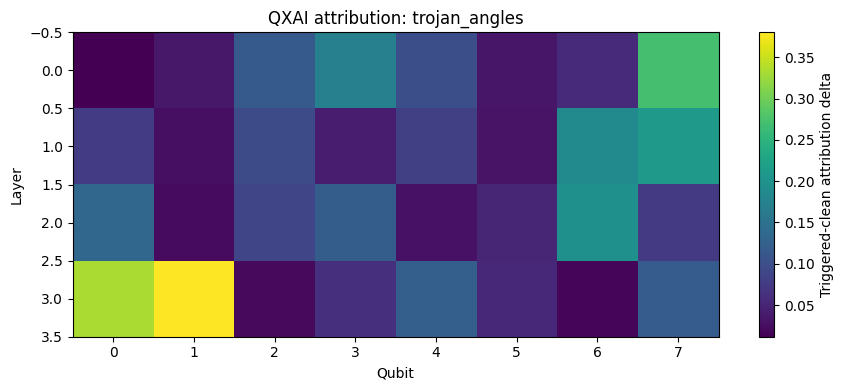

Saved: ./qmedshield_final_outputs/qxai_trojan_angles_heatmap.png
[repair:hard_reset] epoch 01, loss=0.9179
[repair:hard_reset] epoch 02, loss=0.8725
[repair:hard_reset] epoch 03, loss=0.8558
Saved repaired checkpoint: ./qmedshield_final_outputs/qmedshield_repaired_hard_reset_seed42.pt


,strategy,parameter_group,repaired_params,total_params,CA_before,ASR_before,CA_after,ASR_after
0,hard_reset,trojan_angles,5,32,0.7025,0.947115,0.864167,0.036859



=== Attack 1 QTrojan: circuit/model-level audit ===
Rebuilt Stage-A clean model from state_dict.


,tau_clean_calibrated,audit_acc,audit_f1,audit_precision,audit_recall,audit_auprc,clean_score_mean,clean_score_p95,trojan_score_mean,trojan_score_p05,n_clean_challenges,n_trojan_challenges
0,0.034841,0.974,0.974659,0.95057,1.0,1.0,0.034426,0.034841,0.650194,0.236881,250,250


audit_score                                          \
                        count      mean       std       min       25%   
audit_model_label                                                       
clean_stage_model       250.0  0.034426  0.002828  0.014407  0.034751   
qtrojan_model           250.0  0.650194  0.408338  0.115139  0.343486   

                                                delta_top4_mean            \
                        50%       75%       max           count      mean   
audit_model_label                                                           
clean_stage_model  0.034795  0.034814  0.047334           250.0  0.032986   
qtrojan_model      0.454181  1.168880  1.388175           250.0  0.481738   

                   ... target_conf_gain           logit_kl_t1_vs_t0            \
                   ...              75%       max             count      mean   
audit_model_label  ...                                                          
clean_stage_model  ...         0.003712  0.007253             250.0  0.000582   
qtrojan_model      ...         0.805349  0.884167             250.0  0.802953   

                                                                               
                        std       min       25%       50%       75%       max  
audit_model_label                                                              
clean_stage_model  0.000197  0.000020  0.000573  0.000574  0.000576  0.002852  
qtrojan_model      0.750717  0.003971  0.250313  0.475902  1.649841  2.748304  

[2 rows x 40 columns]

Saved: ./qmedshield_final_outputs/attack1_qtrojan_model_audit_challenge_scores.csv
Saved: ./qmedshield_final_outputs/attack1_qtrojan_model_audit_metrics.csv


In [6]:
# ============================================================
# S15-S17. QXAI PARAMETER-SHIFT + CIRCUIT REPAIR
# ============================================================

def select_source_examples(X, y, cfg, n, seed):
    idx = np.where(y.cpu().numpy() == cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for QXAI.")
    rng = np.random.default_rng(seed)
    if len(idx) > n:
        idx = rng.choice(idx, size=n, replace=False)
    idx = np.sort(idx)
    return X[idx], y[idx]

def get_vqc_param(model, name):
    if name == "trojan_angles":
        return model.vqc.trojan_angles
    if name == "weights":
        return model.vqc.weights
    raise ValueError("repair_parameter_name must be 'trojan_angles' or 'weights'.")

@torch.no_grad()
def target_logit_score(model, X_raw, cfg, device, t_value, target_class):
    model.eval()
    vals = []
    for s in range(0, len(X_raw), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X_raw))
        xb = preprocess_for_resnet(X_raw[s:e].to(device), cfg.model_image_size)
        logits = model(xb, t=t_value)
        vals.append(logits[:, target_class].cpu())
    return torch.cat(vals).mean().item()

def parameter_shift_attr(model, X_raw, cfg, device, parameter_name, t_value, target_class):
    param = get_vqc_param(model, parameter_name)
    attr = torch.zeros_like(param, device="cpu")
    shift = math.pi / 2.0
    model = model.to(device).eval()
    for idx in np.ndindex(tuple(param.shape)):
        with torch.no_grad():
            orig = param[idx].detach().clone()
            param[idx] = orig + shift
        plus = target_logit_score(model, X_raw, cfg, device, t_value, target_class)
        with torch.no_grad():
            param[idx] = orig - shift
        minus = target_logit_score(model, X_raw, cfg, device, t_value, target_class)
        with torch.no_grad():
            param[idx] = orig
        attr[idx] = abs((plus - minus) / 2.0)
    return attr.numpy()

def compute_qxai_delta(model, X_source, cfg, device):
    print("Parameter-shift attribution on:", cfg.repair_parameter_name)
    a_trig = parameter_shift_attr(model, X_source, cfg, device, cfg.repair_parameter_name, 1.0, cfg.target_class)
    a_clean = parameter_shift_attr(model, X_source, cfg, device, cfg.repair_parameter_name, 0.0, cfg.target_class)
    return a_clean, a_trig, a_trig - a_clean

def build_repair_mask(delta_attr, top_k_pct):
    cutoff = np.percentile(delta_attr.reshape(-1), 100 * (1 - top_k_pct))
    return delta_attr >= cutoff, float(cutoff)

def plot_qxai_heatmap(delta_attr, cfg):
    arr = delta_attr.mean(axis=-1) if delta_attr.ndim == 3 else delta_attr
    plt.figure(figsize=(9, 4))
    plt.imshow(arr, aspect="auto")
    plt.colorbar(label="Triggered-clean attribution delta")
    plt.xlabel("Qubit"); plt.ylabel("Layer")
    plt.title(f"QXAI attribution: {cfg.repair_parameter_name}")
    plt.tight_layout()
    path = os.path.join(cfg.out_dir, f"qxai_{cfg.repair_parameter_name}_heatmap.png")
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

def clone_qmedshield_model_for_repair(model, cfg, device):
    """
    Rebuild-and-load clone for PennyLane models.

    Do NOT use copy.deepcopy(model) here: PennyLane Lightning devices contain
    non-pickleable C++ statevector objects, which causes
    TypeError: cannot pickle '...StateVectorC128' object.
    """
    # Avoid re-downloading ImageNet weights during cloning; all learned parameters
    # are immediately overwritten from the trained model state_dict.
    clone_cfg = QMedShieldConfig(**asdict(cfg))
    clone_cfg.use_imagenet_weights = False
    repaired = QMedShieldHybridQNN(clone_cfg).to(device)

    state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    repaired.load_state_dict(state, strict=True)
    repaired.cfg = cfg
    return repaired

def apply_circuit_repair(model, mask_np, cfg, clean_loader, device, strategy="hard_reset"):
    repaired = clone_qmedshield_model_for_repair(model, cfg, device)
    param = get_vqc_param(repaired, cfg.repair_parameter_name)
    mask = torch.tensor(mask_np, dtype=torch.bool, device=param.device)
    if strategy not in ["hard_reset", "soft_freeze"]:
        raise ValueError("Unknown repair strategy.")

    if strategy == "hard_reset":
        with torch.no_grad():
            param[mask] = 0.0

    # Freeze selected suspicious parameters during clean fine-tuning.
    # For hard_reset this prevents reset parameters from immediately relearning the trigger.
    multiplier = (~mask).to(dtype=param.dtype, device=param.device)
    hook_handle = param.register_hook(lambda grad: grad * multiplier)

    set_trainable(repaired.stem, False)
    set_trainable(repaired.rnn, False)
    set_trainable(repaired.vqc, True)
    set_trainable(repaired.q_head, True)

    opt = torch.optim.AdamW([p for p in repaired.parameters() if p.requires_grad], lr=cfg.repair_lr, weight_decay=cfg.weight_decay)
    for ep in range(1, cfg.repair_finetune_epochs + 1):
        repaired.train()
        loss_sum, n = 0.0, 0
        for xb, yb in clean_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()
            logits = repaired(xb, t=0.0)
            loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)
        print(f"[repair:{strategy}] epoch {ep:02d}, loss={loss_sum/max(n,1):.4f}")

    # Avoid accumulating hooks if this cell is run repeatedly.
    hook_handle.remove()
    return repaired

repair_results_df = pd.DataFrame()

if RUN_QXAI_REPAIR and primary_artifact is not None:
    X_source_qxai, _ = select_source_examples(X_test_raw, y_test_raw, cfg, cfg.qxai_n_examples, cfg.primary_seed)
    attr_clean, attr_trig, delta_attr = compute_qxai_delta(primary_artifact["model"], X_source_qxai, cfg, DEVICE)
    print("QXAI attribution target:", cfg.repair_parameter_name)
    print("delta_attr shape:", delta_attr.shape)
    if cfg.repair_parameter_name == "trojan_angles":
        assert delta_attr.shape == (cfg.vqc_layers, cfg.n_qubits), delta_attr.shape
        print("Attribution is over inserted QTrojan RY gates: [layers, qubits].")
    elif cfg.repair_parameter_name == "weights":
        assert delta_attr.shape == (cfg.vqc_layers, cfg.n_qubits, 3), delta_attr.shape
        print("Attribution is over generic Rot weights: [layers, qubits, 3].")
    repair_mask, cutoff = build_repair_mask(delta_attr, cfg.repair_top_k_pct)
    print(f"Repair cutoff={cutoff:.6f}; selected={repair_mask.sum()}/{repair_mask.size}")
    plot_qxai_heatmap(delta_attr, cfg)

    rows = []
    for strategy in cfg.repair_strategies:
        repaired = apply_circuit_repair(primary_artifact["model"], repair_mask, cfg, primary_artifact["train_loader"], DEVICE, strategy)
        X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, cfg.primary_seed)
        ca_after = evaluate_classifier(repaired, X_test_limited, y_test_limited, cfg, DEVICE, 0.0)
        asr_after = evaluate_qtrojan_asr(repaired, X_test_raw, y_test_raw, cfg, DEVICE, cfg.primary_seed)
        rows.append({
            "strategy": strategy,
            "parameter_group": cfg.repair_parameter_name,
            "repaired_params": int(repair_mask.sum()),
            "total_params": int(repair_mask.size),
            "CA_before": primary_artifact["clean_eval"]["accuracy"],
            "ASR_before": primary_artifact["asr_eval"]["accuracy"],
            "CA_after": ca_after["accuracy"],
            "ASR_after": asr_after["accuracy"],
        })
        if SAVE_CHECKPOINTS:
            path = os.path.join(cfg.out_dir, f"qmedshield_repaired_{strategy}_seed{cfg.primary_seed}.pt")
            torch.save({"model_state_dict": repaired.state_dict(), "config": asdict(cfg)}, path)
            print("Saved repaired checkpoint:", path)
    repair_results_df = pd.DataFrame(rows)
    display(repair_results_df)
    repair_results_df.to_csv(os.path.join(cfg.out_dir, "defense_b_repair_results.csv"), index=False)
else:
    print("QXAI/repair skipped.")


# ------------------------------------------------------------
# QTrojan behavioral audit: model-level circuit-compromise check
# ------------------------------------------------------------
@torch.no_grad()

def rebuild_qmedshield_from_state_dict(state_dict, cfg, device, label="model"):
    """Rebuild a QMedShield model from tensors only. Safe for PennyLane Lightning."""
    local_cfg = QMedShieldConfig(**asdict(cfg))
    local_cfg.use_imagenet_weights = False
    m = QMedShieldHybridQNN(local_cfg).to(device)
    tensor_state = {k: v.detach().cpu().clone() for k, v in state_dict.items()}
    m.load_state_dict(tensor_state, strict=True)
    m.cfg = cfg
    m.eval()
    print(f"Rebuilt {label} from state_dict.")
    return m

@torch.no_grad()
def qtrojan_audit_features(model, X_test, y_test, cfg, device, n_samples=200, seed=42, label="model"):
    """
    Per-challenge audit features for QTrojan circuit compromise.

    This is NOT poisonous-image detection. Each row is a source-class challenge input
    used to probe whether the model has a hidden QTrojan response when t switches 0→1.
    """
    y_np = y_test.cpu().numpy() if isinstance(y_test, torch.Tensor) else np.asarray(y_test)
    src_idx = np.where(y_np == cfg.source_class)[0]
    if len(src_idx) == 0:
        raise ValueError("No source-class samples for QTrojan audit.")
    rng = np.random.default_rng(seed)
    if len(src_idx) > n_samples:
        src_idx = rng.choice(src_idx, n_samples, replace=False)
    src_idx = np.sort(src_idx)
    X_src = X_test[src_idx]

    rows = []
    model.eval()
    for s in range(0, len(X_src), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X_src))
        xb = preprocess_for_resnet(X_src[s:e].to(device), cfg.model_image_size)
        b = xb.shape[0]
        zeros = torch.zeros(b, device=device)
        ones = torch.ones(b, device=device)
        logits0, q0, _ = model(xb, trojan_mask=zeros, return_measurements=True)
        logits1, q1, _ = model(xb, trojan_mask=ones, return_measurements=True)
        p0 = torch.softmax(logits0, dim=1).detach().cpu().numpy()
        p1 = torch.softmax(logits1, dim=1).detach().cpu().numpy()
        q0n = q0.detach().cpu().numpy()
        q1n = q1.detach().cpu().numpy()
        d = np.abs(q1n - q0n)
        kl = np.sum(p1 * (np.log(p1 + 1e-8) - np.log(p0 + 1e-8)), axis=1)
        target_gain = p1[:, cfg.target_class] - p0[:, cfg.target_class]
        for j in range(b):
            top4 = np.sort(d[j])[-min(4, d.shape[1]):]
            rows.append({
                "audit_model_label": label,
                "challenge_index": int(src_idx[s+j]),
                "delta_mean": float(d[j].mean()),
                "delta_max": float(d[j].max()),
                "delta_top4_mean": float(top4.mean()),
                "delta_l2": float(np.linalg.norm(q1n[j] - q0n[j])),
                "target_conf_gain": float(target_gain[j]),
                "logit_kl_t1_vs_t0": float(kl[j]),
                "pred_t0": int(p0[j].argmax()),
                "pred_t1": int(p1[j].argmax()),
                "target_prob_t0": float(p0[j, cfg.target_class]),
                "target_prob_t1": float(p1[j, cfg.target_class]),
            })
    df = pd.DataFrame(rows)
    # Robust but simple score: measurement shift + target confidence gain + probability-distribution shift.
    # No labels from the trojan model are used to create this score.
    df["audit_score"] = (
        0.45 * df["delta_top4_mean"]
        + 0.25 * df["delta_l2"]
        + 0.20 * df["target_conf_gain"].clip(lower=0)
        + 0.10 * df["logit_kl_t1_vs_t0"].clip(lower=0)
    )
    return df

def evaluate_qtrojan_model_audit(clean_df, trojan_df, cfg):
    """
    Model/circuit-level F1. Unit of detection = compromised circuit response on challenge inputs.
    Threshold is calibrated on clean model scores at configured 5% FPR.
    """
    clean_scores = clean_df["audit_score"].to_numpy()
    trojan_scores = trojan_df["audit_score"].to_numpy()
    tau = float(np.percentile(clean_scores, (1 - cfg.fpr_target) * 100))
    y_true = np.concatenate([np.zeros(len(clean_scores), dtype=int), np.ones(len(trojan_scores), dtype=int)])
    scores = np.concatenate([clean_scores, trojan_scores])
    pred = (scores > tau).astype(int)
    return {
        "tau_clean_calibrated": tau,
        "audit_acc": float(accuracy_score(y_true, pred)),
        "audit_f1": float(f1_score(y_true, pred, zero_division=0)),
        "audit_precision": float(precision_score(y_true, pred, zero_division=0)),
        "audit_recall": float(recall_score(y_true, pred, zero_division=0)),
        "audit_auprc": float(average_precision_score(y_true, scores)),
        "clean_score_mean": float(clean_scores.mean()),
        "clean_score_p95": float(np.percentile(clean_scores, 95)),
        "trojan_score_mean": float(trojan_scores.mean()),
        "trojan_score_p05": float(np.percentile(trojan_scores, 5)),
        "n_clean_challenges": int(len(clean_scores)),
        "n_trojan_challenges": int(len(trojan_scores)),
    }

qtrojan_audit_df = pd.DataFrame()
qtrojan_audit_metrics_df = pd.DataFrame()
if primary_artifact is not None:
    print("\n=== Attack 1 QTrojan: circuit/model-level audit ===")
    clean_model_for_audit = rebuild_qmedshield_from_state_dict(
        primary_artifact["clean_model_state_dict"], cfg, DEVICE, label="Stage-A clean model"
    )
    trojan_model_for_audit = primary_artifact["model"]

    clean_audit = qtrojan_audit_features(clean_model_for_audit, X_test_raw, y_test_raw, cfg, DEVICE,
                                         n_samples=max(100, min(250, cfg.max_asr_n)), seed=cfg.primary_seed,
                                         label="clean_stage_model")
    trojan_audit = qtrojan_audit_features(trojan_model_for_audit, X_test_raw, y_test_raw, cfg, DEVICE,
                                          n_samples=max(100, min(250, cfg.max_asr_n)), seed=cfg.primary_seed,
                                          label="qtrojan_model")
    audit_metrics = evaluate_qtrojan_model_audit(clean_audit, trojan_audit, cfg)
    qtrojan_audit_df = pd.concat([clean_audit, trojan_audit], ignore_index=True)
    qtrojan_audit_metrics_df = pd.DataFrame([audit_metrics])

    display(qtrojan_audit_metrics_df)
    display(qtrojan_audit_df.groupby("audit_model_label")[["audit_score", "delta_top4_mean", "delta_l2", "target_conf_gain", "logit_kl_t1_vs_t0"]].describe())

    qtrojan_audit_df.to_csv(os.path.join(cfg.out_dir, "attack1_qtrojan_model_audit_challenge_scores.csv"), index=False)
    qtrojan_audit_metrics_df.to_csv(os.path.join(cfg.out_dir, "attack1_qtrojan_model_audit_metrics.csv"), index=False)
    print("Saved:", os.path.join(cfg.out_dir, "attack1_qtrojan_model_audit_challenge_scores.csv"))
    print("Saved:", os.path.join(cfg.out_dir, "attack1_qtrojan_model_audit_metrics.csv"))



## S18–S21. Phase-2 attack/defense implementation

This section now contains two levels:

1. **Single-dataset helper functions** for Blend, FIBA-style FFT amplitude injection, Defense-A sanitization, and QMRS.
2. **Full multi-dataset experiment logic** for the intended final scope:
   - BloodMNIST → QTrojan branch is handled by the main pipeline above.
   - DermaMNIST → Blend data-level backdoor branch.
   - PathMNIST → FIBA-style frequency-domain backdoor branch.

The multi-dataset branch is disabled by default because it trains additional hybrid QNNs and can be slow. Set `RUN_PHASE2_MULTIDATASET_ATTACKS=True` after the BloodMNIST/QTrojan branch is stable.

No Phase-2 result is claimed unless its cells are actually executed.


In [ ]:

# ============================================================
# S18-S21. PHASE-2 ATTACK/DEFENSE IMPLEMENTATION
# ============================================================

# -----------------------------
# Generic dataset utilities
# -----------------------------

def clone_cfg(base_cfg, **overrides):
    """Create a dataset-specific config without mutating the BloodMNIST config."""
    d = asdict(base_cfg)
    d.update(overrides)
    return QMedShieldConfig(**d)

def load_dataset_bundle(dataset_name, base_cfg, seed, max_train_n=None):
    """Load a MedMNIST dataset and return tensors, metadata, label map, and counts."""
    X_train, y_train, info = load_medmnist_split(dataset_name, "train", download=True)
    X_val, y_val, _ = load_medmnist_split(dataset_name, "val", download=True)
    X_test, y_test, _ = load_medmnist_split(dataset_name, "test", download=True)
    label_map = label_map_to_int(info.get("label", {}))
    if not label_map:
        label_map = {int(c): f"class_{int(c)}" for c in sorted(np.unique(y_train.cpu().numpy()).tolist())}
    counts = pd.Series(y_train.cpu().numpy()).value_counts().sort_index()
    return {
        "dataset_name": dataset_name,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "info": info,
        "label_map": label_map,
        "counts": counts,
    }

def resolve_or_select_class_pair(label_map, y_train, source_hint=None, target_hint=None,
                                 source_class=None, target_class=None, dataset_name="dataset"):
    """
    Resolve class ids from hints when available. If no verified class pair is supplied,
    select the two largest classes for a runnable experiment and record a needs-verification warning.
    """
    y_np = y_train.cpu().numpy() if isinstance(y_train, torch.Tensor) else np.asarray(y_train)
    counts = pd.Series(y_np).value_counts().sort_values(ascending=False)

    def resolve_one(hint, fallback, role):
        if fallback is not None:
            return int(fallback)
        if hint:
            matches = [i for i, name in label_map.items() if str(hint).lower() in str(name).lower()]
            if len(matches) == 1:
                return int(matches[0])
        return None

    s = resolve_one(source_hint, source_class, "source")
    t = resolve_one(target_hint, target_class, "target")

    if s is None or t is None or s == t:
        candidates = [int(c) for c in counts.index.tolist()]
        if len(candidates) < 2:
            raise ValueError(f"{dataset_name}: need at least two classes for source-target attack.")
        s_auto, t_auto = candidates[0], candidates[1]
        if s is None:
            s = s_auto
        if t is None or t == s:
            t = t_auto if t_auto != s else candidates[2]
        msg = (
            f"needs verification: {dataset_name} source/target class pair was auto-selected "
            f"as {s}->{t} using training class counts. Replace with supervisor-approved class ids "
            f"before final reporting."
        )
        print("[warning]", msg)
        NEEDS_VERIFICATION.append(msg)

    return int(s), int(t)

def make_train_val_split_from_tensors(X, y, local_cfg, seed):
    """Generic version of make_train_val_split for non-BloodMNIST datasets."""
    X_lim, y_lim, keep = stratified_limit_tensors(X, y, local_cfg.max_train_n, seed)
    idx = np.arange(len(y_lim))
    tr, va = train_test_split(idx, test_size=local_cfg.val_size, random_state=seed, stratify=y_lim.cpu().numpy())
    tr, va = np.sort(tr), np.sort(va)
    return {"X_train": X_lim[tr], "y_train": y_lim[tr], "X_val": X_lim[va], "y_val": y_lim[va], "source_idx": keep}

# -----------------------------
# Data-level attacks: Blend + FIBA-style
# -----------------------------

def fixed_blend_trigger(shape, seed):
    rng = np.random.default_rng(seed)
    C, H, W = shape
    return torch.tensor(rng.random((C, H, W)), dtype=torch.float32)

def apply_blend(X, trigger, alpha):
    return ((1-alpha) * X + alpha * trigger.to(X.device)).clamp(0, 1)

def make_blend_poisoned_tensors(X, y, local_cfg, poison_rate, seed):
    y_np = y.cpu().numpy()
    source_idx = np.where(y_np == local_cfg.source_class)[0]
    if len(source_idx) == 0:
        raise ValueError("No source-class samples available for Blend poisoning.")
    rng = np.random.default_rng(seed)
    n_poison = max(1, int(round(len(source_idx) * poison_rate)))
    n_poison = min(n_poison, len(source_idx))
    poison_idx = np.sort(rng.choice(source_idx, size=n_poison, replace=False))
    Xp, yp = X.clone(), y.clone()
    mask = torch.zeros(len(X), dtype=torch.bool)
    trigger = fixed_blend_trigger(tuple(X.shape[1:]), seed)
    Xp[poison_idx] = apply_blend(Xp[poison_idx], trigger, local_cfg.blend_alpha)
    yp[poison_idx] = local_cfg.target_class
    mask[poison_idx] = True
    return Xp, yp, mask, trigger

@torch.no_grad()
def evaluate_blend_asr(model, X, y, trigger, local_cfg, device, seed):
    idx = np.where(y.cpu().numpy() == local_cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for Blend ASR.")
    rng = np.random.default_rng(seed)
    if local_cfg.max_asr_n and len(idx) > local_cfg.max_asr_n:
        idx = rng.choice(idx, local_cfg.max_asr_n, replace=False)
    idx = np.sort(idx)
    Xtr = apply_blend(X[idx], trigger, local_cfg.blend_alpha)
    ytar = torch.full((len(idx),), local_cfg.target_class, dtype=torch.long)
    out = evaluate_classifier(model, Xtr, ytar, local_cfg, device, 0.0)
    out["n_source_eval"] = len(idx)
    return out

def make_fiba_amplitude_template(shape, seed):
    """Create a fixed frequency-domain amplitude template from a random reference image."""
    rng = np.random.default_rng(seed)
    C, H, W = shape
    ref = rng.random((C, H, W)).astype(np.float32)
    return np.abs(np.fft.fft2(ref, axes=(-2, -1))).astype(np.float32)

def apply_fiba_amplitude_injection(X, amplitude_template, strength=0.10):
    """
    FIBA-style FFT amplitude injection.
    This implements the plan-level idea: replace/mix part of the input amplitude spectrum
    with a fixed trigger amplitude while keeping the original phase.
    """
    X_np = X.detach().cpu().numpy().astype(np.float32)
    template = np.asarray(amplitude_template, dtype=np.float32)
    out = np.empty_like(X_np)
    for i in range(len(X_np)):
        fft = np.fft.fft2(X_np[i], axes=(-2, -1))
        amp, phase = np.abs(fft), np.angle(fft)
        scale = np.maximum(amp.mean(axis=(-2, -1), keepdims=True), 1e-6)
        tscale = np.maximum(template.mean(axis=(-2, -1), keepdims=True), 1e-6)
        template_scaled = template / tscale * scale
        amp_mixed = (1 - strength) * amp + strength * template_scaled
        out[i] = np.real(np.fft.ifft2(amp_mixed * np.exp(1j * phase), axes=(-2, -1)))
    return torch.tensor(np.clip(out, 0, 1), dtype=torch.float32)

def make_fiba_poisoned_tensors(X, y, local_cfg, poison_rate, seed):
    y_np = y.cpu().numpy()
    source_idx = np.where(y_np == local_cfg.source_class)[0]
    if len(source_idx) == 0:
        raise ValueError("No source-class samples available for FIBA-style poisoning.")
    rng = np.random.default_rng(seed)
    n_poison = max(1, int(round(len(source_idx) * poison_rate)))
    n_poison = min(n_poison, len(source_idx))
    poison_idx = np.sort(rng.choice(source_idx, size=n_poison, replace=False))
    Xp, yp = X.clone(), y.clone()
    mask = torch.zeros(len(X), dtype=torch.bool)
    amp_template = make_fiba_amplitude_template(tuple(X.shape[1:]), seed)
    Xp[poison_idx] = apply_fiba_amplitude_injection(Xp[poison_idx], amp_template, strength=local_cfg.fiba_strength)
    yp[poison_idx] = local_cfg.target_class
    mask[poison_idx] = True
    return Xp, yp, mask, amp_template

@torch.no_grad()
def evaluate_fiba_asr(model, X, y, amp_template, local_cfg, device, seed):
    idx = np.where(y.cpu().numpy() == local_cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for FIBA-style ASR.")
    rng = np.random.default_rng(seed)
    if local_cfg.max_asr_n and len(idx) > local_cfg.max_asr_n:
        idx = rng.choice(idx, local_cfg.max_asr_n, replace=False)
    idx = np.sort(idx)
    Xtr = apply_fiba_amplitude_injection(X[idx], amp_template, strength=local_cfg.fiba_strength)
    ytar = torch.full((len(idx),), local_cfg.target_class, dtype=torch.long)
    out = evaluate_classifier(model, Xtr, ytar, local_cfg, device, 0.0)
    out["n_source_eval"] = len(idx)
    return out

# Backwards-compatible alias from the earlier notebook version.
def apply_fiba_lite(X, strength=0.10, seed=42):
    amp_template = make_fiba_amplitude_template(tuple(X.shape[1:]), seed)
    return apply_fiba_amplitude_injection(X, amp_template, strength=strength)

# -----------------------------
# Defense-A sanitization
# -----------------------------

def detector_score_matrix(A, detector):
    V = detector["reducer"].transform(A)
    centers = detector["kmeans"].cluster_centers_
    bd = detector["backdoor_cluster"]
    d_bd = np.linalg.norm(V - centers[bd], axis=1)
    others = [j for j in range(len(centers)) if j != bd]
    d_other = np.min(np.stack([np.linalg.norm(V - centers[j], axis=1) for j in others], axis=1), axis=1)
    return d_other - d_bd

@torch.no_grad()
def extract_measurements_for_tensors(model, X, local_cfg, device, t_value=0.0):
    model.eval()
    q_all, ctx_all, pred_all = [], [], []
    for s in range(0, len(X), local_cfg.eval_batch_size):
        e = min(s + local_cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), local_cfg.model_image_size)
        logits, qfeat, ctx = model(xb, t=t_value, return_measurements=True)
        q_all.append(qfeat.cpu())
        ctx_all.append(ctx.cpu())
        pred_all.append(logits.argmax(dim=1).cpu())
    return torch.cat(q_all).numpy(), torch.cat(ctx_all).numpy(), torch.cat(pred_all).numpy()

def fit_poison_detector_on_training(model, X_train_poisoned, poison_mask, local_cfg, seed, device):
    A_train, C_train, _ = extract_measurements_for_tensors(model, X_train_poisoned, local_cfg, device, t_value=0.0)
    detector = fit_kmeans_minority_detector(A_train, poison_mask.numpy().astype(bool), local_cfg, seed)
    train_scores = detector_score_matrix(A_train, detector)
    return detector, train_scores, A_train, C_train

def sanitize_by_threshold(Xp, yp, poison_mask, train_scores, tau):
    keep_mask = np.asarray(train_scores) <= tau
    removed = ~keep_mask
    poison_np = poison_mask.cpu().numpy().astype(bool)
    stats = {
        "removed_total": int(removed.sum()),
        "removed_rate": float(removed.mean()),
        "poison_removal_recall": float((removed & poison_np).sum() / max(poison_np.sum(), 1)),
        "clean_false_removal_rate": float((removed & ~poison_np).sum() / max((~poison_np).sum(), 1)),
        "remaining_train_n": int(keep_mask.sum()),
    }
    return Xp[keep_mask], yp[keep_mask], keep_mask, stats

def train_data_attack_model(X_train_attack, y_train_attack, X_val, y_val, local_cfg, seed, device):
    X_train_aug = augment_train_only(X_train_attack, seed)
    train_loader = make_loader(X_train_aug, y_train_attack, local_cfg.train_batch_size, True)
    val_loader = make_loader(X_val, y_val, local_cfg.eval_batch_size, False)
    model = QMedShieldHybridQNN(local_cfg).to(device)
    verify_architecture(model, local_cfg, device)
    model, hist = train_clean_stage(model, train_loader, val_loader, local_cfg, device)
    return model, train_loader, val_loader, pd.DataFrame(hist)

# -----------------------------
# Optional Grad-CAM for data-level attacks
# -----------------------------

def gradcam_resnet_stem(model, X_raw, local_cfg, target_class, device, out_path, title="Grad-CAM"):
    """Generate a Grad-CAM map from the last ResNet stem block for one or more images."""
    if len(X_raw) == 0:
        print("No image supplied for Grad-CAM.")
        return None
    model.eval().to(device)
    x = preprocess_for_resnet(X_raw[:1].to(device), local_cfg.model_image_size)
    acts, grads = {}, {}
    target_layer = model.stem[-1]

    def fwd_hook(module, inp, out):
        acts["value"] = out
    def bwd_hook(module, grad_in, grad_out):
        grads["value"] = grad_out[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)
    try:
        model.zero_grad(set_to_none=True)
        logits = model(x, t=0.0)
        score = logits[:, target_class].sum()
        score.backward()
        A = acts["value"].detach()
        G = grads["value"].detach()
        weights = G.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * A).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=X_raw.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        plt.figure(figsize=(4, 4))
        plt.imshow(X_raw[0].permute(1, 2, 0).cpu().numpy())
        plt.imshow(cam.cpu().numpy(), alpha=0.45)
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(out_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)
        return cam.cpu().numpy()
    finally:
        h1.remove(); h2.remove()

# -----------------------------
# Single-dataset Phase-2 runners
# -----------------------------

def run_data_level_attack_experiment(spec, base_cfg, seed, device):
    """
    Full logic for one non-QTrojan Phase-2 experiment:
    load dataset -> resolve class pair -> poison train set -> train attacked model ->
    evaluate CA/ASR -> fit CC-QMC-style detector -> calibrate threshold on clean val ->
    sanitize training set -> retrain -> evaluate CA/ASR after defense.
    """
    dataset_name = spec["dataset_name"]
    attack_name = spec["attack"].lower()
    print("\n" + "="*90)
    print(f"Phase-2 experiment: {dataset_name} | attack={attack_name} | seed={seed}")
    print("="*90)

    bundle = load_dataset_bundle(dataset_name, base_cfg, seed)
    label_map = bundle["label_map"]
    source_class, target_class = resolve_or_select_class_pair(
        label_map,
        bundle["y_train"],
        source_hint=spec.get("source_hint"),
        target_hint=spec.get("target_hint"),
        source_class=spec.get("source_class"),
        target_class=spec.get("target_class"),
        dataset_name=dataset_name,
    )
    local_cfg = clone_cfg(
        base_cfg,
        dataset_name=dataset_name,
        n_classes=len(label_map),
        source_class=source_class,
        target_class=target_class,
        model_image_size=spec.get("model_image_size", base_cfg.model_image_size),
        max_train_n=spec.get("max_train_n", base_cfg.max_train_n),
        max_clean_test_n=spec.get("max_clean_test_n", base_cfg.max_clean_test_n),
        max_asr_n=spec.get("max_asr_n", base_cfg.max_asr_n),
        train_batch_size=spec.get("train_batch_size", base_cfg.train_batch_size),
        eval_batch_size=spec.get("eval_batch_size", base_cfg.eval_batch_size),
        clean_epochs=spec.get("clean_epochs", base_cfg.clean_epochs),
        qtrojan_epochs=0,  # not used for data-level attacks
        detection_pair_n=spec.get("detection_pair_n", base_cfg.detection_pair_n),
        kmeans_n_init=spec.get("kmeans_n_init", base_cfg.kmeans_n_init),
        blend_alpha=spec.get("blend_alpha", base_cfg.blend_alpha),
        fiba_strength=spec.get("fiba_strength", base_cfg.fiba_strength),
    )
    print(f"Class pair: {source_class} ({label_map.get(source_class)}) -> {target_class} ({label_map.get(target_class)})")

    split = make_train_val_split_from_tensors(bundle["X_train"], bundle["y_train"], local_cfg, seed)
    poison_rate = spec.get("poison_rate", 0.10)

    if attack_name == "blend":
        Xp, yp, poison_mask, trigger_obj = make_blend_poisoned_tensors(split["X_train"], split["y_train"], local_cfg, poison_rate, seed)
        asr_fn = lambda model: evaluate_blend_asr(model, bundle["X_test"], bundle["y_test"], trigger_obj, local_cfg, device, seed)
        trigger_preview = apply_blend(split["X_train"][:4], trigger_obj, local_cfg.blend_alpha)
    elif attack_name in ["fiba", "fiba_style", "fiba-lite"]:
        Xp, yp, poison_mask, trigger_obj = make_fiba_poisoned_tensors(split["X_train"], split["y_train"], local_cfg, poison_rate, seed)
        asr_fn = lambda model: evaluate_fiba_asr(model, bundle["X_test"], bundle["y_test"], trigger_obj, local_cfg, device, seed)
        trigger_preview = apply_fiba_amplitude_injection(split["X_train"][:4], trigger_obj, strength=local_cfg.fiba_strength)
    else:
        raise ValueError(f"Unsupported Phase-2 attack: {attack_name}")

    # Visual check: clean vs triggered examples
    preview_path = os.path.join(local_cfg.out_dir, f"{dataset_name}_{attack_name}_trigger_preview.png")
    plt.figure(figsize=(8, 4))
    for i in range(min(4, len(trigger_preview))):
        plt.subplot(2, 4, i+1)
        plt.imshow(split["X_train"][i].permute(1, 2, 0).cpu().numpy())
        plt.title("clean")
        plt.axis("off")
        plt.subplot(2, 4, i+5)
        plt.imshow(trigger_preview[i].permute(1, 2, 0).cpu().numpy())
        plt.title(attack_name)
        plt.axis("off")
    plt.tight_layout(); plt.savefig(preview_path, dpi=180, bbox_inches="tight"); plt.show()
    print("Saved:", preview_path)

    # 1) Train attacked model.
    attack_model, attack_train_loader, attack_val_loader, attack_hist = train_data_attack_model(
        Xp, yp, split["X_val"], split["y_val"], local_cfg, seed, device
    )
    X_test_limited, y_test_limited, _ = stratified_limit_tensors(bundle["X_test"], bundle["y_test"], local_cfg.max_clean_test_n, seed)
    ca_before = evaluate_classifier(attack_model, X_test_limited, y_test_limited, local_cfg, device, 0.0)
    asr_before = asr_fn(attack_model)
    print(f"Before sanitization: CA={ca_before['accuracy']:.4f} | ASR={asr_before['accuracy']:.4f}")

    # 2) Fit CC-QMC-style poison detector on attacked training measurements.
    detector, train_scores, A_train, C_train = fit_poison_detector_on_training(
        attack_model, Xp, poison_mask, local_cfg, seed, device
    )
    A_val, _, _ = extract_measurements_for_tensors(attack_model, split["X_val"], local_cfg, device, t_value=0.0)
    clean_val_scores = detector_score_matrix(A_val, detector)
    tau = float(np.percentile(clean_val_scores, (1 - local_cfg.fpr_target) * 100))
    X_san, y_san, keep_mask, sanitize_stats = sanitize_by_threshold(Xp, yp, poison_mask, train_scores, tau)
    print("Sanitization stats:", sanitize_stats)

    # 3) Retrain from scratch on sanitized training set.
    sanitized_model, san_train_loader, san_val_loader, san_hist = train_data_attack_model(
        X_san, y_san, split["X_val"], split["y_val"], local_cfg, seed, device
    )
    ca_after = evaluate_classifier(sanitized_model, X_test_limited, y_test_limited, local_cfg, device, 0.0)
    asr_after = asr_fn(sanitized_model)
    print(f"After sanitization: CA={ca_after['accuracy']:.4f} | ASR={asr_after['accuracy']:.4f}")

    # 4) Optional Grad-CAM on one triggered source example.
    try:
        src_idx = np.where(bundle["y_test"].cpu().numpy() == local_cfg.source_class)[0]
        if len(src_idx):
            gradcam_path = os.path.join(local_cfg.out_dir, f"{dataset_name}_{attack_name}_gradcam.png")
            if attack_name == "blend":
                X_cam = apply_blend(bundle["X_test"][src_idx[:1]], trigger_obj, local_cfg.blend_alpha)
            else:
                X_cam = apply_fiba_amplitude_injection(bundle["X_test"][src_idx[:1]], trigger_obj, strength=local_cfg.fiba_strength)
            gradcam_resnet_stem(attack_model, X_cam, local_cfg, local_cfg.target_class, device, gradcam_path,
                                title=f"{dataset_name} {attack_name} target-class Grad-CAM")
    except Exception as exc:
        msg = f"needs verification: Grad-CAM failed for {dataset_name}/{attack_name}: {exc}"
        print("[warning]", msg)
        NEEDS_VERIFICATION.append(msg)

    # 5) Save compact result.
    row = {
        "dataset": dataset_name,
        "attack": attack_name,
        "seed": seed,
        "source_class": local_cfg.source_class,
        "target_class": local_cfg.target_class,
        "source_name": label_map.get(local_cfg.source_class),
        "target_name": label_map.get(local_cfg.target_class),
        "poison_rate": poison_rate,
        "poisoned_train_n": int(poison_mask.sum()),
        "CA_before": ca_before["accuracy"],
        "ASR_before": asr_before["accuracy"],
        "detector_f1_on_known_poison_mask": detector["metrics"]["det_f1"],
        "detector_precision_on_known_poison_mask": detector["metrics"]["det_precision"],
        "detector_recall_on_known_poison_mask": detector["metrics"]["det_recall"],
        "tau_5pct_clean_val_fpr": tau,
        "removed_rate": sanitize_stats["removed_rate"],
        "poison_removal_recall": sanitize_stats["poison_removal_recall"],
        "clean_false_removal_rate": sanitize_stats["clean_false_removal_rate"],
        "CA_after_sanitization": ca_after["accuracy"],
        "ASR_after_sanitization": asr_after["accuracy"],
    }
    return {
        "row": row,
        "local_cfg": local_cfg,
        "bundle": bundle,
        "attack_model": attack_model,
        "sanitized_model": sanitized_model,
        "detector": detector,
        "train_scores": train_scores,
        "poison_mask": poison_mask,
        "attack_history": attack_hist,
        "sanitized_history": san_hist,
    }


# ------------------------------------------------------------
# real-trigger detection pools + matched classical CONTROL baseline
# NOTE: this baseline is used only to prove whether the QNN/VQC measurement branch adds value.
# The proposed model remains QMedShieldHybridQNN with StrongVQCMeasurementLayer.
# ------------------------------------------------------------
class ClassicalResNetBiGRU(nn.Module):
    """Classical CONTROL baseline only: same ResNet-18 stem and BiGRU bridge, intentionally without VQC.\n    This baseline is NOT the proposed model. The proposed QMedShield model remains QMedShieldHybridQNN,\n    which uses StrongVQCMeasurementLayer and the PennyLane quantum circuit."""
    def __init__(self, local_cfg):
        super().__init__()
        self.cfg = local_cfg
        weights = None
        if local_cfg.use_imagenet_weights:
            try:
                weights = ResNet18_Weights.IMAGENET1K_V1
            except Exception:
                weights = None
        try:
            resnet = models.resnet18(weights=weights)
        except Exception:
            resnet = models.resnet18(weights=None)
        self.stem = nn.Sequential(*list(resnet.children())[:-2])
        if local_cfg.freeze_resnet_lower_blocks:
            for p in self.stem[:6].parameters():
                p.requires_grad = False
        self.rnn = nn.GRU(input_size=512, hidden_size=256, num_layers=2,
                          batch_first=True, bidirectional=True, dropout=0.2)
        self.head = nn.Linear(512, local_cfg.n_classes)

    def context(self, x_preprocessed):
        feats = self.stem(x_preprocessed)
        B, C, H, W = feats.shape
        seq = feats.view(B, C, H*W).permute(0, 2, 1)
        out, _ = self.rnn(seq)
        return out.mean(dim=1)

    def forward(self, x_preprocessed, return_context=False):
        ctx = self.context(x_preprocessed)
        logits = self.head(ctx)
        if return_context:
            return logits, ctx
        return logits

def train_classical_stage(model, train_loader, val_loader, local_cfg, device, label="classical"):
    model = model.to(device)
    opt = torch.optim.AdamW([
        {"params": model.stem[6:].parameters(), "lr": local_cfg.lr_base * 0.1},
        {"params": model.rnn.parameters(), "lr": local_cfg.lr_base},
        {"params": model.head.parameters(), "lr": local_cfg.lr_base},
    ], weight_decay=local_cfg.weight_decay)
    hist = []
    print(f"[{label}] training: {local_cfg.clean_epochs} epochs")
    for ep in range(1, local_cfg.clean_epochs + 1):
        model.train(); loss_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), local_cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb, label_smoothing=local_cfg.label_smoothing)
            loss.backward(); opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb); n += len(xb)
        val = evaluate_classical_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], local_cfg, device)
        row = {"epoch": ep, "stage": label, "loss": loss_sum/max(n,1), "val_acc": val["accuracy"], "val_macro_f1": val["macro_f1"]}
        hist.append(row)
        print(f"[{label}] Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_acc']:.4f}")
    return model, hist

@torch.no_grad()
def evaluate_classical_classifier(model, X, y, local_cfg, device):
    model.eval()
    loader = make_loader(X, y, local_cfg.eval_batch_size, shuffle=False)
    preds, probs = [], []
    for xb, _ in loader:
        xb = preprocess_for_resnet(xb.to(device), local_cfg.model_image_size)
        logits = model(xb)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        preds.append(prob.argmax(axis=1)); probs.append(prob)
    preds = np.concatenate(preds); probs = np.concatenate(probs)
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    return {"accuracy": float(accuracy_score(y_np, preds)), "macro_f1": float(f1_score(y_np, preds, average="macro", zero_division=0)), "preds": preds, "probs": probs}

@torch.no_grad()
def evaluate_classical_trigger_asr(model, X, y, trigger_obj, attack_name, local_cfg, device, seed):
    y_np = y.cpu().numpy()
    idx = np.where(y_np == local_cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for classical ASR.")
    rng = np.random.default_rng(seed)
    if local_cfg.max_asr_n and len(idx) > local_cfg.max_asr_n:
        idx = rng.choice(idx, local_cfg.max_asr_n, replace=False)
    idx = np.sort(idx)
    if attack_name == "blend":
        Xtr = apply_blend(X[idx], trigger_obj, local_cfg.blend_alpha)
    else:
        Xtr = apply_fiba_amplitude_injection(X[idx], trigger_obj, strength=local_cfg.fiba_strength)
    ytar = torch.full((len(idx),), local_cfg.target_class, dtype=torch.long)
    out = evaluate_classical_classifier(model, Xtr, ytar, local_cfg, device)
    out["n_source_eval"] = int(len(idx))
    return out

@torch.no_grad()
def extract_classical_context(model, X, local_cfg, device):
    model.eval(); ctx_all, pred_all = [], []
    for s in range(0, len(X), local_cfg.eval_batch_size):
        e = min(s + local_cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), local_cfg.model_image_size)
        logits, ctx = model(xb, return_context=True)
        ctx_all.append(ctx.cpu()); pred_all.append(logits.argmax(dim=1).cpu())
    return torch.cat(ctx_all).numpy(), torch.cat(pred_all).numpy()

def train_classical_data_attack_model(X_train_attack, y_train_attack, X_val, y_val, local_cfg, seed, device):
    X_train_aug = augment_train_only(X_train_attack, seed)
    train_loader = make_loader(X_train_aug, y_train_attack, local_cfg.train_batch_size, True)
    val_loader = make_loader(X_val, y_val, local_cfg.eval_batch_size, False)
    model = ClassicalResNetBiGRU(local_cfg).to(device)
    model, hist = train_classical_stage(model, train_loader, val_loader, local_cfg, device, label="classical_baseline")
    return model, train_loader, val_loader, pd.DataFrame(hist)

def apply_attack_to_test_source(X_source, trigger_obj, attack_name, local_cfg):
    if attack_name == "blend":
        return apply_blend(X_source.clone(), trigger_obj, local_cfg.blend_alpha)
    if attack_name in ["fiba", "fiba_style", "fiba-lite"]:
        return apply_fiba_amplitude_injection(X_source.clone(), trigger_obj, strength=local_cfg.fiba_strength)
    raise ValueError(f"Unsupported attack for detection pool: {attack_name}")

def build_real_trigger_detection_pool(X_test, y_test, trigger_obj, attack_name, local_cfg, seed, n_per_group=None, backdoor_fraction=0.10):
    """
    Data-level poisonous-image detection pool for Blend/FIBA.

    This follows QSentry's minority-cluster assumption more closely:
      clean_source ≈ n
      clean_target ≈ n
      triggered_source ≈ backdoor_fraction * n

    The backdoor group contains physically modified images. This is the valid
    poisonous-image detection setting for Attack 2 and Attack 3.
    """
    n_clean_target = int(n_per_group or local_cfg.detection_pair_n)
    y_np = y_test.cpu().numpy()
    source_idx = np.where(y_np == local_cfg.source_class)[0]
    target_idx = np.where(y_np == local_cfg.target_class)[0]
    if len(source_idx) < 30 or len(target_idx) < 10:
        raise ValueError(f"Insufficient source/target samples for detection pool: source={len(source_idx)}, target={len(target_idx)}")

    rng = np.random.default_rng(seed)
    sp = rng.permutation(source_idx)
    tp = rng.permutation(target_idx)

    # Choose clean count first, then poisonous/triggered minority count.
    n_clean = min(n_clean_target, len(target_idx), max(10, int(len(source_idx) * 0.80)))
    n_bd = max(5, int(round(n_clean * float(backdoor_fraction))))
    if n_clean + n_bd > len(source_idx):
        n_bd = max(5, len(source_idx) - n_clean)
    if n_bd <= 0:
        raise ValueError(f"No source samples left for triggered group: source={len(source_idx)}, n_clean={n_clean}")

    clean_source_idx = sp[:n_clean]
    backdoor_source_idx = sp[n_clean:n_clean+n_bd]
    clean_target_idx = tp[:n_clean]

    X_clean_source = X_test[clean_source_idx]
    X_clean_target = X_test[clean_target_idx]
    X_backdoor_source = apply_attack_to_test_source(X_test[backdoor_source_idx], trigger_obj, attack_name, local_cfg)

    X_det = torch.cat([X_clean_source, X_clean_target, X_backdoor_source], dim=0)
    is_backdoor = np.concatenate([
        np.zeros(n_clean, dtype=bool),
        np.zeros(n_clean, dtype=bool),
        np.ones(n_bd, dtype=bool),
    ])
    group_names = np.array(["clean_source"]*n_clean + ["clean_target"]*n_clean + ["poisonous_image_triggered_source"]*n_bd)
    original_indices = np.concatenate([clean_source_idx, clean_target_idx, backdoor_source_idx])
    print(f"[{attack_name} poisonous-image pool] {n_clean} clean-source + {n_clean} clean-target + {n_bd} triggered-source = {len(X_det)} total; poisonous rate={is_backdoor.mean():.3f}")
    return {
        "X_det": X_det,
        "is_backdoor": is_backdoor,
        "group_names": group_names,
        "original_indices": original_indices,
        "n_clean_per_class": int(n_clean),
        "n_backdoor": int(n_bd),
    }

def compare_qnn_vs_classical_text(row):
    delta_ca = row.get("QNN_CA_before", np.nan) - row.get("Classical_CA_before", np.nan)
    delta_asr = row.get("QNN_ASR_before", np.nan) - row.get("Classical_ASR_before", np.nan)
    return f"QNN-Classic CA Δ={delta_ca:.3f}, ASR Δ={delta_asr:.3f} (positive means QNN higher)."

def run_data_level_attack_experiment_v2(spec, base_cfg, seed, device):
    """
    v6 runner: trains QNN and matched classical baseline, evaluates CA/ASR,
    and runs real-trigger test-pool detection for Raw/Ctx/CC-QMC.
    """
    dataset_name = spec["dataset_name"]
    attack_name = spec["attack"].lower()
    print("\n" + "="*90)
    print(f"Phase-2 v6: {dataset_name} | attack={attack_name} | seed={seed}")
    print("="*90)

    bundle = load_dataset_bundle(dataset_name, base_cfg, seed)
    label_map = bundle["label_map"]
    source_class, target_class = resolve_or_select_class_pair(
        label_map, bundle["y_train"], source_hint=spec.get("source_hint"), target_hint=spec.get("target_hint"),
        source_class=spec.get("source_class"), target_class=spec.get("target_class"), dataset_name=dataset_name)
    local_cfg = clone_cfg(
        base_cfg, dataset_name=dataset_name, n_classes=len(label_map), source_class=source_class, target_class=target_class,
        model_image_size=spec.get("model_image_size", base_cfg.model_image_size), max_train_n=spec.get("max_train_n", base_cfg.max_train_n),
        max_clean_test_n=spec.get("max_clean_test_n", base_cfg.max_clean_test_n), max_asr_n=spec.get("max_asr_n", base_cfg.max_asr_n),
        train_batch_size=spec.get("train_batch_size", base_cfg.train_batch_size), eval_batch_size=spec.get("eval_batch_size", base_cfg.eval_batch_size),
        clean_epochs=spec.get("clean_epochs", base_cfg.clean_epochs), qtrojan_epochs=0, detection_pair_n=spec.get("detection_pair_n", base_cfg.detection_pair_n),
        kmeans_n_init=spec.get("kmeans_n_init", base_cfg.kmeans_n_init), blend_alpha=spec.get("blend_alpha", base_cfg.blend_alpha),
        fiba_strength=spec.get("fiba_strength", base_cfg.fiba_strength),)
    print(f"Class pair: {source_class} ({label_map.get(source_class)}) -> {target_class} ({label_map.get(target_class)})")
    split = make_train_val_split_from_tensors(bundle["X_train"], bundle["y_train"], local_cfg, seed)
    poison_rate = spec.get("poison_rate", 0.10)
    if attack_name == "blend":
        Xp, yp, poison_mask, trigger_obj = make_blend_poisoned_tensors(split["X_train"], split["y_train"], local_cfg, poison_rate, seed)
        qnn_asr_fn = lambda model: evaluate_blend_asr(model, bundle["X_test"], bundle["y_test"], trigger_obj, local_cfg, device, seed)
    elif attack_name in ["fiba", "fiba_style", "fiba-lite"]:
        Xp, yp, poison_mask, trigger_obj = make_fiba_poisoned_tensors(split["X_train"], split["y_train"], local_cfg, poison_rate, seed)
        qnn_asr_fn = lambda model: evaluate_fiba_asr(model, bundle["X_test"], bundle["y_test"], trigger_obj, local_cfg, device, seed)
    else:
        raise ValueError(f"Unsupported Phase-2 attack: {attack_name}")
    print(f"Poisoned {int(poison_mask.sum())}/{len(poison_mask)} train samples ({100*float(poison_mask.float().mean()):.2f}%).")

    # Train QNN attacked model
    qnn_model, qnn_train_loader, _, qnn_hist = train_data_attack_model(Xp, yp, split["X_val"], split["y_val"], local_cfg, seed, device)
    X_test_limited, y_test_limited, _ = stratified_limit_tensors(bundle["X_test"], bundle["y_test"], local_cfg.max_clean_test_n, seed)
    qnn_ca = evaluate_classifier(qnn_model, X_test_limited, y_test_limited, local_cfg, device, 0.0)
    qnn_asr = qnn_asr_fn(qnn_model)

    # Train matched classical baseline on the exact same poisoned tensors
    classical_ca = {"accuracy": np.nan, "macro_f1": np.nan}; classical_asr = {"accuracy": np.nan}
    classical_model = None
    if globals().get("RUN_CLASSICAL_BASELINES", True):
        classical_model, _, _, classical_hist = train_classical_data_attack_model(Xp, yp, split["X_val"], split["y_val"], local_cfg, seed, device)
        classical_ca = evaluate_classical_classifier(classical_model, X_test_limited, y_test_limited, local_cfg, device)
        classical_asr = evaluate_classical_trigger_asr(classical_model, bundle["X_test"], bundle["y_test"], trigger_obj, attack_name, local_cfg, device, seed)
    print(f"QNN CA={qnn_ca['accuracy']:.3f}, ASR={qnn_asr['accuracy']:.3f} | Classical CA={classical_ca['accuracy']:.3f}, ASR={classical_asr['accuracy']:.3f}")

    # Real triggered test detection: this is where Blend/FIBA are sample-level detectable
    det = build_real_trigger_detection_pool(
        bundle["X_test"], bundle["y_test"], trigger_obj, attack_name, local_cfg, seed,
        n_per_group=local_cfg.detection_pair_n,
        backdoor_fraction=poison_rate,
    )
    X_det, is_backdoor, group_names = det["X_det"], det["is_backdoor"], det["group_names"]
    A_q, A_ctx, _ = extract_measurements_for_tensors(qnn_model, X_det, local_cfg, device, t_value=0.0)
    raw_flat = X_det.reshape(len(X_det), -1).numpy().astype(np.float32)
    det_rows = []
    detectors = {
        f"{attack_name}_Raw_K3_Pixels": fit_kmeans_minority_detector(raw_flat, is_backdoor, local_cfg, seed, group_names=group_names),
        f"{attack_name}_Ctx_K3_QNN_BiGRU": fit_kmeans_minority_detector(A_ctx, is_backdoor, local_cfg, seed, group_names=group_names),
        f"{attack_name}_CC_QMC_K3": fit_kmeans_minority_detector(A_q, is_backdoor, local_cfg, seed, group_names=group_names),
    }
    if classical_model is not None:
        C_classical, _ = extract_classical_context(classical_model, X_det, local_cfg, device)
        detectors[f"{attack_name}_Ctx_K3_Classical_BiGRU"] = fit_kmeans_minority_detector(C_classical, is_backdoor, local_cfg, seed, group_names=group_names)
    for name, out in detectors.items():
        row = {"dataset": dataset_name, "attack": attack_name, "method": name, "source_class": source_class, "target_class": target_class,
               "QNN_CA_before": qnn_ca["accuracy"], "QNN_ASR_before": qnn_asr["accuracy"],
               "Classical_CA_before": classical_ca["accuracy"], "Classical_ASR_before": classical_asr["accuracy"],
               "poison_rate": poison_rate, "blend_alpha": local_cfg.blend_alpha, "fiba_strength": local_cfg.fiba_strength}
        row.update(out["metrics"]); det_rows.append(row)
    detection_df = pd.DataFrame(det_rows).sort_values("det_f1", ascending=False)
    display(detection_df)
    det_path = os.path.join(local_cfg.out_dir, f"{dataset_name}_{attack_name}_real_trigger_detection_and_classical.csv")
    detection_df.to_csv(det_path, index=False)
    print("Saved:", det_path)

    # v7: Save a per-image poisonous-image detection report using the CC-QMC detector.
    cc_keys = [k for k in detectors.keys() if "CC_QMC" in k]
    if cc_keys:
        cc_key = cc_keys[0]
        cc = detectors[cc_key]
        poison_report = pd.DataFrame({
            "dataset": dataset_name,
            "attack": attack_name,
            "original_test_index": det.get("original_indices", np.arange(len(is_backdoor))),
            "group": group_names,
            "true_poisonous_image": is_backdoor.astype(int),
            "pred_poisonous_image": cc["pred"].astype(int),
            "cc_qmc_score": cc["scores"],
            "cluster_id": cc["cluster_ids"],
        })
        poison_path = os.path.join(local_cfg.out_dir, f"{dataset_name}_{attack_name}_poisonous_image_report_cc_qmc.csv")
        poison_report.to_csv(poison_path, index=False)
        print("Saved poisonous-image report:", poison_path)

    summary_row = {
        "experiment_id": spec.get("experiment_id", f"{dataset_name}_{attack_name}"), "dataset": dataset_name, "attack": attack_name,
        "source_class": source_class, "target_class": target_class, "source_name": label_map.get(source_class), "target_name": label_map.get(target_class),
        "poison_rate": poison_rate, "poisoned_train_n": int(poison_mask.sum()),
        "QNN_CA_before": qnn_ca["accuracy"], "QNN_ASR_before": qnn_asr["accuracy"],
        "Classical_CA_before": classical_ca["accuracy"], "Classical_ASR_before": classical_asr["accuracy"],
        "best_detection_method": str(detection_df.iloc[0]["method"]), "best_detection_f1": float(detection_df.iloc[0]["det_f1"]),
        "CC_QMC_F1": float(detection_df.loc[detection_df["method"].str.contains("CC_QMC"), "det_f1"].max()) if any(detection_df["method"].str.contains("CC_QMC")) else np.nan,
        "Raw_K3_F1": float(detection_df.loc[detection_df["method"].str.contains("Raw_K3"), "det_f1"].max()) if any(detection_df["method"].str.contains("Raw_K3")) else np.nan,
    }
    print(compare_qnn_vs_classical_text(summary_row))
    return {"row": summary_row, "local_cfg": local_cfg, "bundle": bundle, "qnn_model": qnn_model, "classical_model": classical_model,
            "trigger_obj": trigger_obj, "detection_df": detection_df, "detectors": detectors}


# -----------------------------
# Intended multi-dataset final scope
# -----------------------------

PHASE2_ATTACK_SPECS = [
    {
        "experiment_id": "dermamnist_blend",
        "enabled": globals().get("RUN_PHASE2_RUN_DERMAMNIST_BLEND", True),
        "dataset_name": "dermamnist",
        "attack": "blend",
        "poison_rate": 0.10,
        "blend_alpha": 0.07,
        # Kaggle-safe caps for Phase-2. Increase after a successful run if stronger evidence is needed.
        "max_train_n": 1200,
        "max_clean_test_n": 400,
        "max_asr_n": 250,
        "clean_epochs": 4,
        "model_image_size": 96,
        "train_batch_size": 48,
        "eval_batch_size": 96,
        "detection_pair_n": 300,
        "kmeans_n_init": 10,
        # Source/target are intentionally not hardcoded. The notebook will auto-select and flag verification.
        "source_class": None,
        "target_class": None,
    },
    {
        "experiment_id": "pathmnist_fiba_style",
        "enabled": globals().get("RUN_PHASE2_RUN_PATHMNIST_FIBA", False),
        "dataset_name": "pathmnist",
        "attack": "fiba_style",
        "poison_rate": 0.10,
        "fiba_strength": cfg.fiba_strength,
        # Kaggle-safe caps for Phase-2. Increase after a successful run if stronger evidence is needed.
        "max_train_n": 1200,
        "max_clean_test_n": 400,
        "max_asr_n": 250,
        "clean_epochs": 4,
        "model_image_size": 96,
        "train_batch_size": 48,
        "eval_batch_size": 96,
        "detection_pair_n": 300,
        "kmeans_n_init": 10,
        # Source/target are intentionally not hardcoded. The notebook will auto-select and flag verification.
        "source_class": None,
        "target_class": None,
    },
]
multidataset_phase2_artifacts = []
multidataset_phase2_df = pd.DataFrame()

if RUN_PHASE2_MULTIDATASET_ATTACKS:
    rows = []
    for spec in PHASE2_ATTACK_SPECS:
        if not spec.get("enabled", True):
            print(f"Skipping disabled Phase-2 spec: {spec['experiment_id']}")
            continue
        artifact = run_data_level_attack_experiment_v2(spec, cfg, cfg.primary_seed, DEVICE)
        multidataset_phase2_artifacts.append(artifact)
        rows.append(artifact["row"])
    multidataset_phase2_df = pd.DataFrame(rows)
    if len(multidataset_phase2_df):
        display(multidataset_phase2_df)
        out_path = os.path.join(cfg.out_dir, "phase2_multidataset_attack_defense_results.csv")
        multidataset_phase2_df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    else:
        print("No Phase-2 specs were enabled.")
else:
    print("Multi-dataset Phase-2 attacks disabled.")
    print("Set RUN_PHASE2_MULTIDATASET_ATTACKS=True to run:")
    for spec in PHASE2_ATTACK_SPECS:
        print(f"- {spec['dataset_name']} / {spec['attack']} / poison_rate={spec.get('poison_rate', 0.10)}")

# -----------------------------
# Legacy single-BloodMNIST Blend/QMRS switches retained for compatibility
# -----------------------------

blend_results_df = pd.DataFrame()

if RUN_PHASE2_BLEND:
    # This optional branch runs Blend on the currently loaded primary dataset only.
    rows = []
    for rho in cfg.blend_poison_rates:
        split = make_train_val_split(X_train_raw, y_train_raw, cfg, cfg.primary_seed)
        Xp, yp, poison_mask, trigger = make_blend_poisoned_tensors(split["X_train"], split["y_train"], cfg, rho, cfg.primary_seed)
        blend_model, _, _, _ = train_data_attack_model(Xp, yp, split["X_val"], split["y_val"], cfg, cfg.primary_seed, DEVICE)
        X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, cfg.primary_seed)
        ca = evaluate_classifier(blend_model, X_test_limited, y_test_limited, cfg, DEVICE, 0.0)
        basr = evaluate_blend_asr(blend_model, X_test_raw, y_test_raw, trigger, cfg, DEVICE, cfg.primary_seed)
        rows.append({"dataset": cfg.dataset_name, "poison_rate": rho, "clean_accuracy": ca["accuracy"], "blend_asr": basr["accuracy"], "asr_n": basr["n_source_eval"]})
    blend_results_df = pd.DataFrame(rows)
    display(blend_results_df)
    blend_results_df.to_csv(os.path.join(cfg.out_dir, "phase2_blend_primary_dataset_results.csv"), index=False)
else:
    print("Legacy single-dataset Blend disabled.")

# -----------------------------
# QMRS: Mahalanobis + K3 + augmentation instability
# -----------------------------

@torch.no_grad()
def build_clean_reference(model, loader, local_cfg, device):
    per_class = {c: [] for c in range(local_cfg.n_classes)}
    for xb, yb in loader:
        qfeat = model.extract_vqc_measurements(xb.to(device), t=0.0).cpu().numpy()
        for i, lab in enumerate(yb.cpu().numpy()):
            per_class[int(lab)].append(qfeat[i])
    mu, inv_cov = {}, {}
    for c, vals in per_class.items():
        arr = np.asarray(vals)
        if len(arr) < 2:
            NEEDS_VERIFICATION.append(f"needs verification: class {c} lacks enough samples for QMRS covariance.")
            continue
        mu[c] = arr.mean(axis=0)
        inv_cov[c] = np.linalg.pinv(np.cov(arr.T) + 1e-5*np.eye(arr.shape[1]))
    return mu, inv_cov

def mahalanobis(m, pred_class, mu, inv_cov):
    if pred_class not in mu:
        return np.nan
    diff = m - mu[pred_class]
    return float(np.sqrt(max(diff @ inv_cov[pred_class] @ diff.T, 0)))

def k3_score_single(m, detector):
    return detector_score_matrix(m.reshape(1, -1), detector)[0]

@torch.no_grad()
def augmentation_instability(model, X, local_cfg, device, seed):
    """Compute ||m_act(x)-m_act(aug(x))||_2 using a deterministic mild horizontal flip/crop-style augmentation."""
    set_all_seeds(seed)
    aug = T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomCrop(X.shape[-1], padding=2, padding_mode="reflect")])
    X_aug = torch.stack([aug(img) for img in X])
    m0, _, _ = extract_measurements_for_tensors(model, X, local_cfg, device, t_value=0.0)
    m1, _, _ = extract_measurements_for_tensors(model, X_aug, local_cfg, device, t_value=0.0)
    return np.linalg.norm(m0 - m1, axis=1), m0, m1

qmrs_df = pd.DataFrame()

if RUN_PHASE2_QMRS and primary_artifact is not None:
    mu, inv_cov = build_clean_reference(primary_artifact["model"], primary_artifact["val_loader"], cfg, DEVICE)
    detector = primary_artifact["methods"]["CC_QMC_PRIMARY_T0_K3"]
    m_base = primary_artifact["A_q_t0"]
    preds = primary_artifact["preds_t0"]
    instability, _, _ = augmentation_instability(primary_artifact["model"], primary_artifact["det"]["X_det"], cfg, DEVICE, cfg.primary_seed)
    def combine_qmrs_scores(m_arr, pred_arr, instab_arr):
        vals = []
        for m, p, instab in zip(m_arr, pred_arr, instab_arr):
            score = (
                cfg.qmrs_alpha * mahalanobis(m, int(p), mu, inv_cov)
                + cfg.qmrs_beta * k3_score_single(m, detector)
                + cfg.qmrs_gamma * float(instab)
            )
            vals.append(score)
        return np.asarray(vals, dtype=np.float32)

    qmrs_scores = combine_qmrs_scores(m_base, preds, instability)

    # Calibrate QMRS threshold on clean validation data, not on the detection pool.
    m_val, _, pred_val = extract_measurements_and_context(
        primary_artifact["model"], primary_artifact["split"]["X_val"], cfg, DEVICE, t_forced=0.0
    )
    instab_val, _, _ = augmentation_instability(
        primary_artifact["model"], primary_artifact["split"]["X_val"], cfg, DEVICE, cfg.primary_seed
    )
    qmrs_val_scores = combine_qmrs_scores(m_val, pred_val, instab_val)
    tau = calibrate_threshold_from_clean_scores(qmrs_val_scores, cfg.fpr_target)
    print("QMRS metrics:", threshold_metrics(qmrs_scores, primary_artifact["det"]["is_backdoor"], tau))
    qmrs_df = pd.DataFrame({"QMRS": qmrs_scores, "is_backdoor": primary_artifact["det"]["is_backdoor"], "group": primary_artifact["det"]["group_names"]})
    display(qmrs_df.head())
    qmrs_df.to_csv(os.path.join(cfg.out_dir, "qmrs_primary_t0_scores.csv"), index=False)
else:
    print("Phase-2 QMRS disabled.")


## v7 Final Scope Lock: three branches, no topic drift

This notebook intentionally separates the three attacks by threat surface:

1. **Attack 1 — QTrojan / BloodMNIST:** circuit-level attack. The output is not poisonous-image detection. The valid task is **detect compromised circuit behavior** using a clean-vs-trojan model audit, then **repair suspicious quantum gates** with QXAI-guided hard-reset/soft-freeze.
2. **Attack 2 — Blend / DermaMNIST:** input-level data poisoning. The output is **poisonous-image detection**: clean-source + clean-target + physically triggered-source images are clustered in raw, classical-context, and quantum-measurement spaces.
3. **Attack 3 — FIBA-style / PathMNIST:** input-level frequency poisoning. The output is **poisonous-image detection** using the same evaluation and classical/QNN comparison protocol.

This is not a shortcut. It is the correct threat-model separation: circuit-level backdoors require circuit audit/repair; data-level backdoors require triggered-image detection/sanitization.

## S22–S24. Multi-seed, K ablation, final report, and limitations

This final section saves the computed outputs and prints remaining risks. It does not rewrite results to match the proposal; the thesis must follow the notebook output.


In [8]:
# ============================================================
# S22-S24. MULTI-SEED, K ABLATION, FINAL REPORT
# ============================================================

multi_seed_df = pd.DataFrame()

if RUN_MULTI_SEED:
    rows = []
    for seed in cfg.seeds:
        art = run_pipeline(seed, cfg, DEVICE)
        rows.extend(art["results_df"].to_dict("records"))
    multi_seed_df = pd.DataFrame(rows)
    display(multi_seed_df)
    multi_seed_summary = (
        multi_seed_df
        .groupby("method")[["clean_accuracy", "asr", "det_f1", "det_precision", "det_recall", "det_auprc"]]
        .agg(["mean", "std"])
    )
    display(multi_seed_summary)
    multi_seed_df.to_csv(os.path.join(cfg.out_dir, "multi_seed_results.csv"), index=False)
    multi_seed_summary.to_csv(os.path.join(cfg.out_dir, "multi_seed_summary_mean_std.csv"))
else:
    print("Multi-seed disabled.")

k_ablation_df = pd.DataFrame()

if RUN_K_ABLATION and primary_artifact is not None:
    rows = []
    A = primary_artifact["A_q_t0"]
    ybd = primary_artifact["det"]["is_backdoor"]
    for k in [2, 3, 4, 5]:
        out = fit_kmeans_minority_detector(A, ybd, cfg, cfg.primary_seed, k=k)
        row = {"k": k}
        row.update(out["metrics"])
        rows.append(row)
    k_ablation_df = pd.DataFrame(rows)
    display(k_ablation_df)
    k_ablation_df.to_csv(os.path.join(cfg.out_dir, "k_ablation_primary_t0.csv"), index=False)
else:
    print("K ablation skipped.")

def list_outputs(out_dir):
    rows = []
    for name in sorted(os.listdir(out_dir)):
        path = os.path.join(out_dir, name)
        if os.path.isfile(path):
            rows.append({"file": name, "size_kb": round(os.path.getsize(path)/1024, 2)})
    return pd.DataFrame(rows)

final_report = {
    "config": asdict(cfg),
    "needs_verification": sorted(set(NEEDS_VERIFICATION)),
    "main_experiment_ran": bool(primary_artifact is not None),
    "repair_ran": bool(not repair_results_df.empty),
    "blend_ran": bool(not blend_results_df.empty),
    "multidataset_phase2_ran": bool("multidataset_phase2_df" in globals() and not multidataset_phase2_df.empty),
    "qmrs_ran": bool(not qmrs_df.empty),
    "multi_seed_ran": bool(not multi_seed_df.empty),
}
report_path = os.path.join(cfg.out_dir, "final_run_report.json")
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2)
print("Saved final report:", report_path)

print("\nNeeds verification:")
if final_report["needs_verification"]:
    for item in final_report["needs_verification"]:
        print("-", item)
else:
    print("- None recorded.")

print("\nHard warnings:")
print("- Do not claim forced-t0 dormant detection as F1≈0.99 unless the notebook actually computes it.")
print("- Trigger-on diagnostic is not the cleanest claim because positives/negatives are unpaired.")
print("- The paired active QTrojan audit is the preferred active-state claim if it performs well.")
print("- If forced-t0 primary detection is weak, say it is a leakage-control/null result, not a project failure.")
print("- Confirm source/target class names from S2 before final reporting.")
print("- Phase-2 DermaMNIST/Blend and PathMNIST/FIBA-style are OFF by default for Kaggle runtime; enable after BloodMNIST/QTrojan is stable.")
print("- Multi-dataset mapping implemented as: BloodMNIST/QTrojan, DermaMNIST/Blend, PathMNIST/FIBA-style; verify Derma/Path source-target class IDs before final reporting.")
print("- Written thesis tables must match this notebook's computed outputs.")

print("\nOutput inventory:")
display(list_outputs(cfg.out_dir))


Multi-seed disabled.


,k,det_acc,det_f1,det_precision,det_recall,det_auprc,true_backdoor_rate,pred_backdoor_rate,mean_silhouette,cluster_counts,selected_cluster
0,2,0.601496,0.335116,0.377510,0.301282,0.396130,0.333333,0.266026,0.449171,"[249, 687]",0
1,3,0.594017,0.293680,0.349558,0.253205,0.376934,0.333333,0.241453,0.568088,"[289, 421, 226]",2
2,4,0.668803,0.088235,0.535714,0.048077,0.446913,0.333333,0.029915,0.619064,"[393, 269, 246, 28]",3
3,5,0.669872,0.088496,0.555556,0.048077,0.442269,0.333333,0.028846,0.665497,"[390, 271, 219, 27, 29]",3


Saved final report: ./qmedshield_final_outputs/final_run_report.json

Needs verification:
- needs verification: dermamnist source/target class pair was auto-selected as 5->4 using training class counts. Replace with supervisor-approved class ids before final reporting.
- needs verification: forced-t0 dormant control is weak. This is expected for a trigger-controlled circuit gate; do not claim old ACTIVE K3 result as forced-t0 detection.
- needs verification: pathmnist source/target class pair was auto-selected as 8->5 using training class counts. Replace with supervisor-approved class ids before final reporting.

Hard warnings:
- Do not claim forced-t0 dormant detection as F1≈0.99 unless the notebook actually computes it.
- Trigger-on diagnostic is not the cleanest claim because positives/negatives are unpaired.
- The paired active QTrojan audit is the preferred active-state claim if it performs well.
- If forced-t0 primary detection is weak, say it is a leakage-control/null result, no

,file,size_kb
0,attack1_qtrojan_model_audit_challenge_scores.csv,99.56
1,attack1_qtrojan_model_audit_metrics.csv,0.34
2,cc_qmc_paired_active_qtrojan_audit_pr.png,45.71
3,cc_qmc_paired_active_qtrojan_audit_roc.png,34.51
4,cc_qmc_primary_t0_pr.png,46.09
5,cc_qmc_primary_t0_roc.png,35.19
6,defense_b_repair_results.csv,0.18
7,dermamnist_blend_poisonous_image_report_cc_qmc...,23.67
8,dermamnist_blend_real_trigger_detection_and_cl...,1.18
9,final_run_report.json,2.43
